# Data Science Lab
## Winter Call, A.Y. 2024/2025

## Age Evaluation from Speech
Alessia Ciccaglione s344499\
Ilaria Parodi s339184

### **Importing Modules**

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random

# Pre-processing
from scipy.stats import boxcox
import librosa
import noisereduce as nr
from scipy.io import wavfile
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.signal import find_peaks
from scipy import stats

#Regression Model and Evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, PowerTransformer, PolynomialFeatures
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor



In [12]:
pip install noisereduce

Note: you may need to restart the kernel to use updated packages.


### **Loading and Preparing the Dataset**

In [13]:
df_dev = pd.read_csv(r"C:\Users\iparo\Desktop\magi\Data Science Lab\Untitled Folder\DSL_Winter_Project_2025\development.csv", index_col=0)
df_eval = pd.read_csv(r"C:\Users\iparo\Desktop\magi\Data Science Lab\Untitled Folder\DSL_Winter_Project_2025\evaluation.csv", index_col=0)

In [14]:
df_dev.head()

,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path
Id,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.6906,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,[151.99908088],-123.999726,69,281,39,23.846893,audios_development/1.wav
1,22050,22.5,female,hungarian,1297.8187,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,[129.19921875],-86.928478,69,281,21,19.388662,audios_development/2.wav
2,22050,22.0,female,portuguese,1332.8524,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,[117.45383523],-98.450670,69,281,1,21.640998,audios_development/3.wav
3,22050,22.0,female,english,1430.3499,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,[117.45383523],-56.459762,69,281,9,19.644127,audios_development/4.wav
4,22050,22.0,male,dutch,1688.7234,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,[112.34714674],-80.349204,69,281,11,18.041905,audios_development/5.wav


### **Data exploration**

In [15]:
df_dev.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2933 entries, 0 to 2932
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sampling_rate           2933 non-null   int64  
 1   age                     2933 non-null   float64
 2   gender                  2933 non-null   object 
 3   ethnicity               2933 non-null   object 
 4   mean_pitch              2933 non-null   float64
 5   max_pitch               2933 non-null   float64
 6   min_pitch               2933 non-null   float64
 7   jitter                  2933 non-null   float64
 8   shimmer                 2933 non-null   float64
 9   energy                  2933 non-null   float64
 10  zcr_mean                2933 non-null   float64
 11  spectral_centroid_mean  2933 non-null   float64
 12  tempo                   2933 non-null   object 
 13  hnr                     2933 non-null   float64
 14  num_words               2933 non-null   int64

In [16]:
df_dev.describe()

,sampling_rate,age,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,hnr,num_words,num_characters,num_pauses,silence_duration
count,2933.0,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000,2933.000000
mean,22050.0,27.897886,1189.536569,3779.570485,146.934930,0.021190,0.107741,0.005208,0.104774,2176.369847,-74.526288,41.307535,167.936243,12.423116,13.501159
std,0.0,13.093316,414.193673,532.847869,3.757917,0.006626,0.029005,0.006074,0.051646,578.925294,38.446856,32.782431,133.816974,14.273205,10.839142
min,22050.0,6.000000,346.974330,935.515560,145.349140,0.007292,0.045205,0.000028,0.015947,692.116731,-193.693345,0.000000,0.000000,1.000000,0.668345
25%,22050.0,19.000000,818.922360,3948.234400,145.419140,0.016734,0.087378,0.001960,0.060733,1740.756716,-104.555692,4.000000,14.000000,1.000000,1.732925
50%,22050.0,23.000000,1208.998300,3998.397200,145.622010,0.020525,0.104697,0.003716,0.098964,2150.814043,-84.415550,69.000000,281.000000,8.000000,17.368526
75%,22050.0,32.000000,1523.777700,3999.485400,146.820890,0.024558,0.124993,0.006338,0.139559,2566.190670,-40.339359,69.000000,281.000000,20.000000,21.408798
max,22050.0,97.000000,2724.892800,3999.792500,202.040700,0.096153,0.265167,0.129114,0.335976,4144.132595,12.403661,69.000000,281.000000,97.000000,83.777596


### **FEATURE EXTRACTION**

In [17]:
path=r"C:\Users\iparo\Desktop\magi\Data Science Lab\Untitled Folder\DSL_Winter_Project_2025\audios_development"

dict_audio = {}
dict_audio = {
    int(os.path.splitext(file)[0]): os.path.join(path, file)
    for file in os.listdir(path)
    if file.endswith(".wav")
}

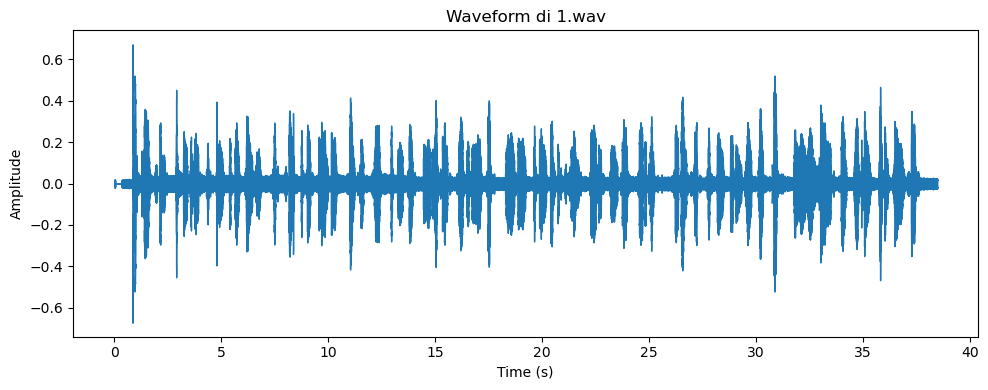

In [18]:
audio_random = random.choice(list(dict_audio.values()))
audio, sr = librosa.load(audio_random, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)
plt.title(f"Waveform di {os.path.basename(audio_random)}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

In [19]:
#The following block of code is used to remove noise using noisereduce.
#It works by computing a spectrogram of a signal and estimating a noise threshold
#for each frequency band of that signal/noise. This threshold is then used to compute a mask,
#which filters out noise below the frequency-varying threshold.

#For convenience during the realization of the project all audio files have been preprocessed and
#stored in a folder to avoid reprocessing them each time, but due to dimension problem we were unable
#of upload that folder.



dict_audio_denoised = {}
for key, file_path in dict_audio.items():
        y, sr = librosa.load(file_path, sr=None)
        reduced_noise = nr.reduce_noise(y=y, sr=sr, stationary=False)
        dict_audio_denoised[key] = (reduced_noise, sr)

#
# output_folder = "audio_denoised"
# os.makedirs(output_folder, exist_ok=True)

# for key, (reduced_noise, sr) in dict_audio_denoised.items():
#     output_path = os.path.join(output_folder, f"output_{key}.wav")
#     sf.write(output_path, reduced_noise, sr)
#     print(f""File saved.": {output_path}")

# " <audio_denoised> is the folder where the cleaned files are stored."

# path=r"C:\Users\iparo\Desktop\magi\Data Science Lab\Untitled Folder\DSL_Winter_Project_2025\audio_denoised"


# dict_audio_denoised = {}
# dict_audio_denoised = {
#     int(os.path.splitext(file)[0].split('_')[-1]): os.path.join(path, file)
#     for file in os.listdir(path)
#     if file.endswith(".wav")
# }
#

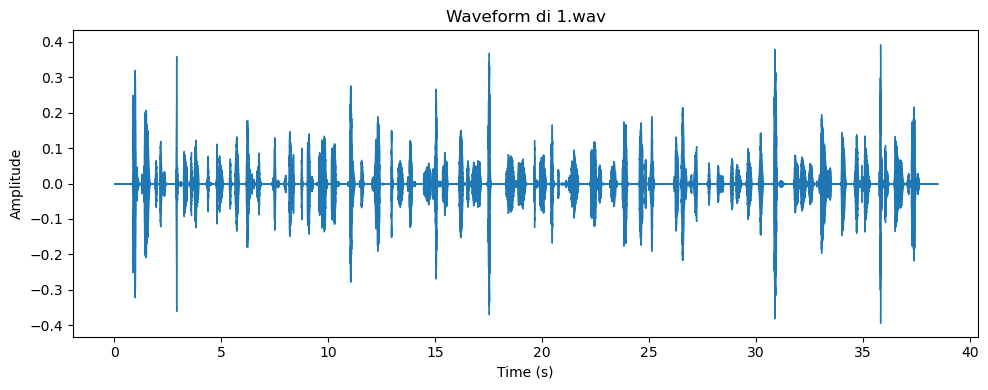

In [20]:
audio_id = [key for key, value in dict_audio.items() if value == audio_random][0] #With noise
(audio_denoised,sr) = dict_audio_denoised.get(audio_id)
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio_denoised, sr=sr)
plt.title(f"Waveform di {audio_id}.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


In [23]:
def features_extraction(x, sr):
    # Compute the Short-Time Fourier Transform (STFT) of the signal and get its squared magnitude
    D = np.abs(librosa.stft(x))**2

    # Calculate the frequencies corresponding to the Fourier spectrum indices
    freqs = librosa.fft_frequencies(sr=sr)

    # Compute the average spectrum across time (mean along the time axis)
    spectrum = np.mean(D, axis=1)

    # Find the peaks in the averaged spectrum with a minimum height proportional to the spectrum's maximum value
    peaks, _ = find_peaks(spectrum, height=0.01 * np.max(spectrum))

    # Extract the frequencies associated with the detected peaks (formants)
    formant_frequencies = freqs[peaks]
    if len(formant_frequencies) > 0:
        formant_1 = formant_frequencies[0]  # First formant
    else:
        formant_1 = 500  # Default value if no formants are found

    # Initialize the features dictionary and store the first formant
    features = {
        "formant_1": formant_1,
    }

    # Ensure the signal is converted to a NumPy array
    x = np.asarray(x)

    # Initialize a dictionary for MFCC features and define the number of MFCCs to extract
    mfcc_features = {}
    n_mfcc = 12

    # Compute the MFCCs (Mel-frequency cepstral coefficients) and take the mean across time
    mfcc = librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).mean(axis=1)

    # Add each MFCC value to the features dictionary with appropriate naming
    for i in range(n_mfcc):
        features[f"mfcc_{i+1}"] = mfcc[i]

    # Return the final dictionary of extracted features
    return features


In [24]:
#Create a dataframe with the newly acoustic extracted features.

dataFrameAudio = []
index_audio = []

for key, (audio,sr) in dict_audio_denoised.items():
    features = features_extraction(audio, sr)
    dataFrameAudio.append(features)
    index_audio.append(key)

df_audio = pd.DataFrame(dataFrameAudio, index=index_audio)
df_audio.index = df_audio.index.astype(int)
df_audio = df_audio.sort_index()

### **Pre_processing**

In [25]:
#Merge the two datasets

audio_id=df_dev['path'].str.extract(r'(\d+)\.wav').astype(int)
df_dev['audio_id'] = audio_id
display(df_dev)
display(df_audio)
df_final = pd.merge(df_dev, df_audio, right_index=True, left_on='audio_id')
display(df_final)


,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,tempo,hnr,num_words,num_characters,num_pauses,silence_duration,path,audio_id
Id,,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.69060,3999.7170,145.43066,0.013795,0.082725,0.002254,0.210093,3112.257251,[151.99908088],-123.999726,69,281,39,23.846893,audios_development/1.wav,1
1,22050,22.5,female,hungarian,1297.81870,3998.8590,145.37268,0.025349,0.096242,0.007819,0.078849,1688.016389,[129.19921875],-86.928478,69,281,21,19.388662,audios_development/2.wav,2
2,22050,22.0,female,portuguese,1332.85240,3998.8025,145.42395,0.019067,0.119456,0.002974,0.105365,2576.901706,[117.45383523],-98.450670,69,281,1,21.640998,audios_development/3.wav,3
3,22050,22.0,female,english,1430.34990,3998.4510,147.98083,0.017004,0.102389,0.022371,0.173701,3269.751413,[117.45383523],-56.459762,69,281,9,19.644127,audios_development/4.wav,4
4,22050,22.0,male,dutch,1688.72340,3998.6113,145.44772,0.028027,0.124831,0.005369,0.107279,1930.897375,[112.34714674],-80.349204,69,281,11,18.041905,audios_development/5.wav,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2928,22050,24.0,male,english,1641.14930,3999.1616,145.39359,0.023647,0.115361,0.001879,0.111799,2188.853478,[184.5703125],-100.921055,69,281,11,17.461406,audios_development/2929.wav,2929
2929,22050,15.0,female,igbo,1089.60050,3984.6550,145.58409,0.015317,0.126740,0.000339,0.070508,2712.362323,[83.35433468],6.757283,0,0,1,1.509206,audios_development/2930.wav,2930
2930,22050,17.0,female,igbo,994.46484,3989.1785,148.97475,0.009677,0.103535,0.001464,0.058442,2248.698477,[89.10290948],-53.913449,1,9,1,1.645034,audios_development/2931.wav,2931


,formant_1,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
1,43.066406,-563.551025,48.835434,2.210797,18.464279,11.274241,4.310649,-1.191183,-2.566468,4.815361,-3.904608,-4.891016,0.948150
2,129.199219,-525.487976,45.264503,10.418957,30.308826,7.526682,10.667743,2.178771,0.485001,-6.440629,-7.247090,-5.633719,-10.282423
3,23.437500,-508.229645,94.342796,2.972573,16.811907,9.597748,16.061209,-4.926746,-1.004643,-2.890360,-4.488954,1.142332,-0.261298


,sampling_rate,age,gender,ethnicity,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,...,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
Id,,,,,,,,,,,,,,,,,,,,,
0,22050,24.0,female,arabic,1821.6906,3999.7170,145.43066,0.013795,0.082725,0.002254,...,2.210797,18.464279,11.274241,4.310649,-1.191183,-2.566468,4.815361,-3.904608,-4.891016,0.948150
1,22050,22.5,female,hungarian,1297.8187,3998.8590,145.37268,0.025349,0.096242,0.007819,...,10.418957,30.308826,7.526682,10.667743,2.178771,0.485001,-6.440629,-7.247090,-5.633719,-10.282423
2,22050,22.0,female,portuguese,1332.8524,3998.8025,145.42395,0.019067,0.119456,0.002974,...,2.972573,16.811907,9.597748,16.061209,-4.926746,-1.004643,-2.890360,-4.488954,1.142332,-0.261298


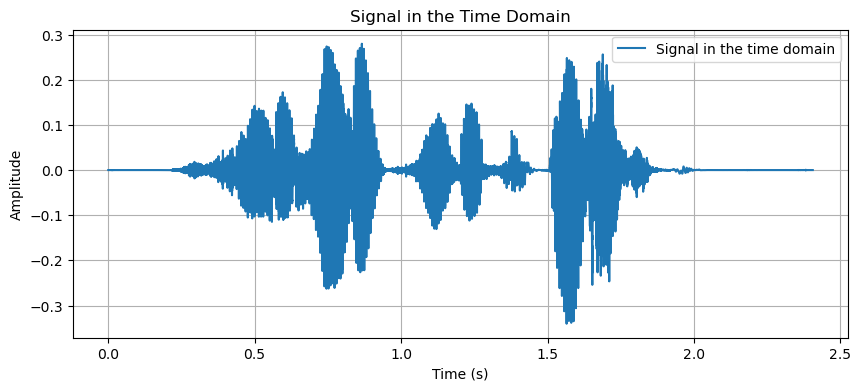

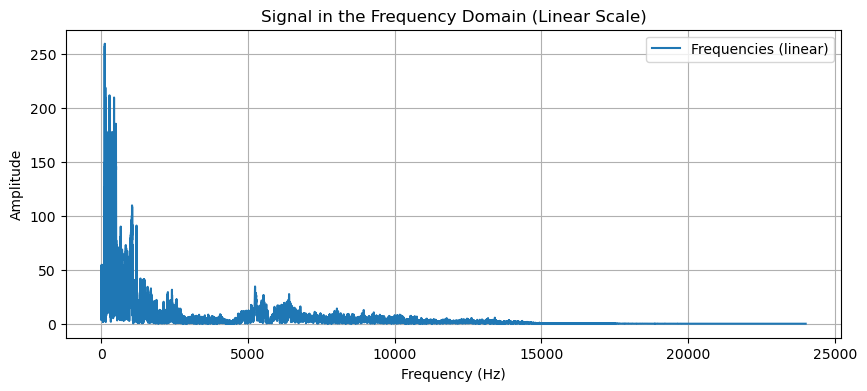

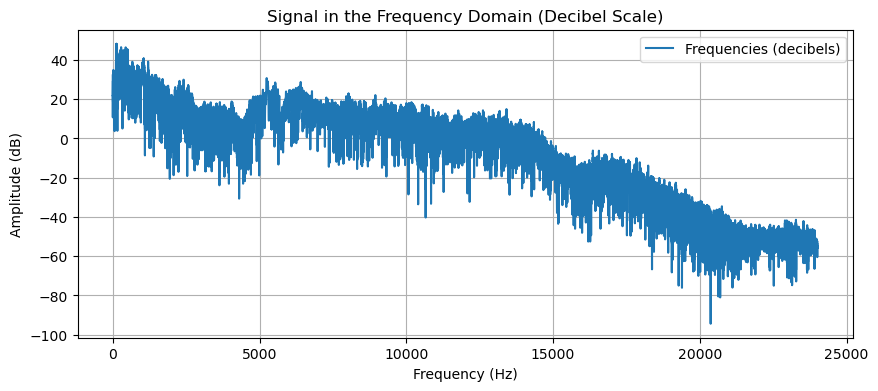

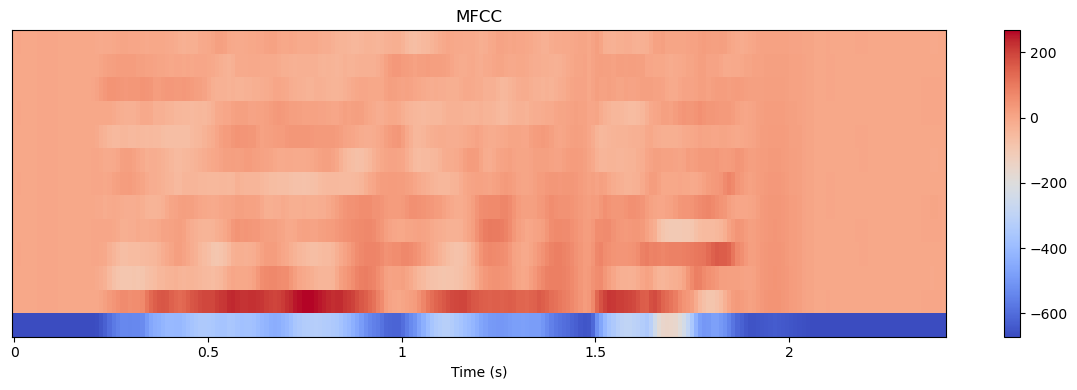

In [27]:
# Choose a random audio file from the dictionary
(signal,fs) = random.choice(list(dict_audio_denoised.values()))

# 1. Time-domain representation
t = np.linspace(0, len(signal) / fs, len(signal), endpoint=False) 
plt.figure(figsize=(10, 4))
plt.plot(t, signal, label="Signal in the time domain")
plt.title("Signal in the Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

# 2. Fourier Transform (Frequency domain)
freqs = np.fft.rfftfreq(len(signal), 1/fs)
fft_values = np.abs(np.fft.rfft(signal))
plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_values, label="Frequencies (linear)")
plt.title("Signal in the Frequency Domain (Linear Scale)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.legend()
plt.show()

# Decibel scale plot
fft_values_db = 20 * np.log10(fft_values + 1e-10)  # Avoid log(0) by adding a small value
plt.figure(figsize=(10, 4))
plt.plot(freqs, fft_values_db, label="Frequencies (decibels)")
plt.title("Signal in the Frequency Domain (Decibel Scale)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dB)")
plt.grid()
plt.legend()
plt.show()

# Compute and plot MFCCs
mfccs = librosa.feature.mfcc(y=signal, sr=fs, n_mfcc=13)
plt.figure(figsize=(12, 4))
librosa.display.specshow(mfccs, sr=fs, x_axis='time')
plt.xlabel("Time (s)")
plt.colorbar()
plt.title('MFCC')
plt.tight_layout()
plt.show()

In [28]:
df_pp = df_final

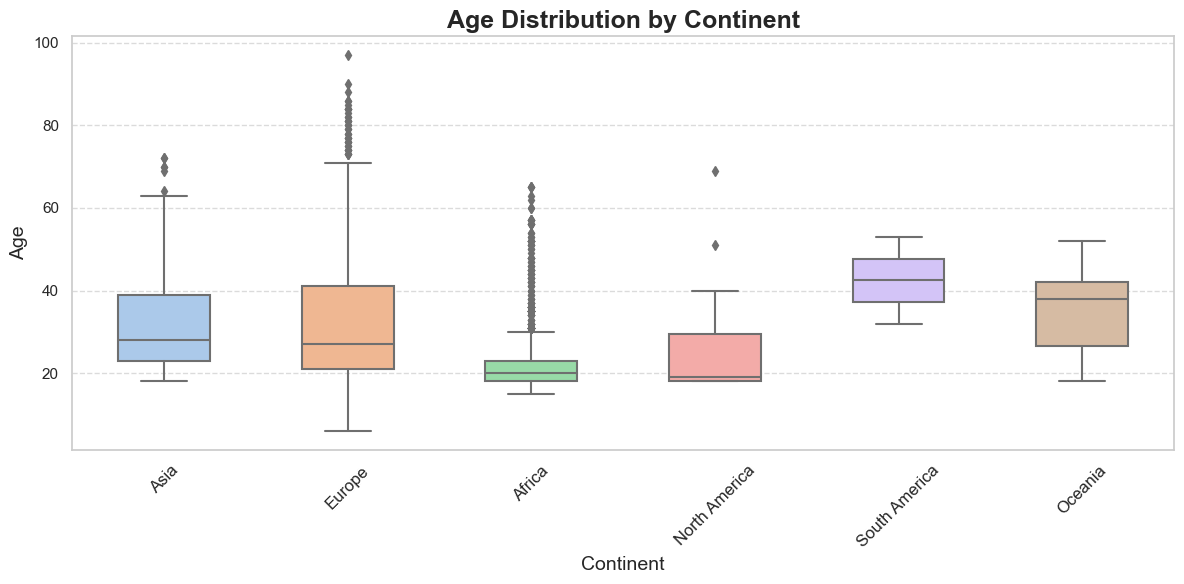

In [ ]:
#A dictionary was created to map ethnicities to their corresponding continents, and the age distribution was analyzed with
#respect to this new feature. Distinctions emerged in the age distribution across continents. Given the high number of
#ethnicities, the decision was made to retain the continent information while removing the ethnicity feature.

ethnicities_to_continent = {
    "arabic": "Asia",
    "hungarian": "Europe",
    "portuguese": "Europe",
    "english": "Europe",
    "dutch": "Europe",
    "italian": "Europe",
    "french": "Europe",
    "igbo": "Africa",
    "hebrew": "Asia",
    "farsi": "Asia",
    "german": "Europe",
    "nama": "Africa",
    "belarusan": "Europe",
    "urhobo": "Africa",
    "polish": "Europe",
    "croatian": "Europe",
    "kikuyu": "Africa",
    "icelandic": "Europe",
    "bengali": "Asia",
    "maltese": "Europe",
    "finnish": "Europe",
    "armenian": "Asia",
    "hindi": "Asia",
    "bosnian": "Europe",
    "miskito": "North America",
    "azerbaijani": "Asia",
    "kiswahili": "Africa",
    "mongolian": "Asia",
    "russian": "Europe",
    "malay": "Asia",
    "bulgarian": "Europe",
    "gan": "Asia",
    "cantonese": "Asia",
    "punjabi": "Asia",
    "nigerian": "Africa",
    "mandarin": "Asia",
    "oriya": "Asia",
    "igala": "Africa",
    "japanese": "Asia",
    "ga": "Africa",
    "ibibio": "Africa",
    "korean": "Asia",
    "amharic": "Africa",
    "gujarati": "Asia",
    "norwegian": "Europe",
    "kurdish": "Asia",
    "congolese": "Africa",
    "marathi": "Asia",
    "ijaw": "Africa",
    "nepali": "Asia",
    "indonesian": "Asia",
    "yoruba": "Africa",
    "bari": "Africa",
    "kanuri": "Africa",
    "pashto": "Asia",
    "romanian": "Europe",
    "albanian": "Europe",
    "georgian": "Asia",
    "baga": "Africa",
    "macedonian": "Europe",
    "danish": "Europe",
    "khmer": "Asia",
    "catalan": "Europe",
    "papiamentu": "North America",
    "naxi": "Asia",
    "czech": "Europe",
    "mizo": "Asia",
    "irish": "Europe",
    "agni": "Africa",
    "hausa": "Africa",
    "estonian": "Europe",
    "ika": "Africa",
    "bafang": "Africa",
    "quechua": "South America",
    "lithuanian": "Europe",
    "afemai": "Africa",
    "ikwerre": "Africa",
    "luxembourgeois": "Europe",
    "moore": "Africa",
    "kabyle": "Africa",
    "fijian": "Oceania",
    "greek": "Europe",
    "mankanya": "Africa",
    "sa'a": "Africa",
    "bai": "Asia",
    "bambara": "Africa",
    "lao": "Asia",
    "konkani": "Asia",
    "ilonggo": "Asia",
    "ewe": "Africa",
    "newari": "Asia",
    "krio": "Africa",
    "oromo": "Africa",
    "garifuna": "North America",
    "hadiyya": "Africa",
    "satawalese": "Oceania",
    "amazigh": "Africa",
    "latvian": "Europe",
    "mandinka": "Africa",
    "obudu": "Africa",
    "ife": "Africa",
    "akan": "Africa",
    "kambaata": "Africa",
    "dari": "Asia",
    "mende": "Africa",
    "mandingo": "Africa",
    "filipino": "Asia",
    "kaire-kaire": "Africa",
    "sarua": "Africa",
    "hmong": "Asia",
    "ukwani": "Africa",
    "lamotrekese": "Oceania",
    "cebuano": "Asia",
    "kru": "Africa",
    "gusii": "Africa",
    "kikongo": "Africa",
    "ngemba": "Africa",
    "pulaar": "Africa",
    "fataluku": "Asia",
    "chichewa": "Africa",
    "rotuman": "Oceania",
    "kirghiz": "Asia",
    "tiv": "Africa",
    "sardinian": "Europe",
    "bavarian": "Europe",
    "edo": "Africa",
    "carolinian": "Oceania",
    "annang": "Africa",
    "hindko": "Asia",
    "ganda": "Africa",
    "rwanda": "Africa",
    "kannada": "Asia",
    "moba": "Africa",
    "indian": "Asia",
    "luo": "Africa",
    "basque": "Europe",
    "kazakh": "Asia",
    "jola": "Africa",
    "ebira": "Africa",
    "fanti": "Africa",
    "mauritian": "Africa",
    "pohnpeian": "Oceania",
    "chamorro": "Oceania",
    "frisian": "Europe",
    "malayalam": "Asia",
    "gedeo": "Africa",
    "lamaholot": "Asia",
    "chittagonian": "Asia",
    "chaldean": "Asia",
    "ashanti": "Africa",
    "nandi": "Africa",
    "bamun": "Africa",
    "kalanga": "Africa",
    "hainanese": "Asia",
    "faroese": "Europe",
    "nuer": "Africa",
    "cameroonian": "Africa",
    "dinka": "Africa",
    "mortlockese": "Oceania",
    "burmese": "Asia",
    "hakka": "Asia",
    "malagasy": "Africa",
    "lingala": "Africa",
    "fang": "Africa",
    "rundi": "Africa",
    "spanish": "Europe",
    "xiang": "Asia",
    "swedish": "Europe",
    "thai": "Asia",
    "ukrainian": "Europe",
    "vietnamese": "Asia",
    "yakut": "Asia",
    "sinhala": "Asia",
    "turkish": "Asia",
    "tamil": "Asia",
    "serbian": "Europe",
    "ikom": "Africa",
    "taiwanese": "Asia",
    "tagalog": "Asia",
    "vlaams": "Europe",
    "urdu": "Asia",
    "yapese": "Oceania",
    "somali": "Africa",
    "taishan": "Asia",
    "tigrigna": "Africa",
    "xasonga": "Africa",
    "uyghur": "Asia",
    "slovenian": "Europe",
    "ekoi": "Africa",
    "slovak": "Europe",
    "susu": "Africa",
    "teochew": "Asia",
    "shan": "Asia",
    "twi": "Africa",
    "sindhi": "Asia",
    "shona": "Africa",
    "okobo": "Africa",
    "okirika": "Africa",
    "tibetan": "Asia",
    "uzbek": "Asia",
    "yiddish": "Europe",
    "zulu": "Africa",
    "fulani": "Africa",
    "wolof": "Africa",
    "yupik": "North America",
    "sesotho": "Africa",
    "telugu": "Asia",
    "shilluk": "Africa",
    "tatar": "Asia",
    "synthesized": "N/A",
    "tajiki": "Asia",
    "temne": "Africa",
    "turkmen": "Asia",
    "sylheti": "Asia",
    "serer": "Africa",
    "lokaa": "Africa",
    "sicilian": "Europe",
    "wu": "Asia",
    "tswana": "Africa",
    "ogoni": "Africa",
    "sundanese": "Asia",
}

df_pp["continent"] = df_pp["ethnicity"].map(ethnicities_to_continent)


sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_pp, x="continent", y="age", order=df_pp["continent"].unique(),
            hue="continent", palette="pastel", width=0.5, dodge=False)
plt.title("Age Distribution by Continent", fontsize=18, fontweight='bold')
plt.xlabel("Continent", fontsize=14)
plt.ylabel("Age", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

df_pp = df_pp.drop(columns=['ethnicity'])

In [ ]:
#The variable "tempo," representing the estimated speaking rate in beats per minute (BPM), is stored as a string. However,
#since it represents a numerical value, it needs to be converted.

df_pp['tempo'] = df_pp['tempo'].astype(str).str.strip("[]")
df_pp['tempo'] = df_pp['tempo'].astype(float)

df_pp_num = df_pp.drop(columns=['continent','gender','path','sampling_rate', 'audio_id'])

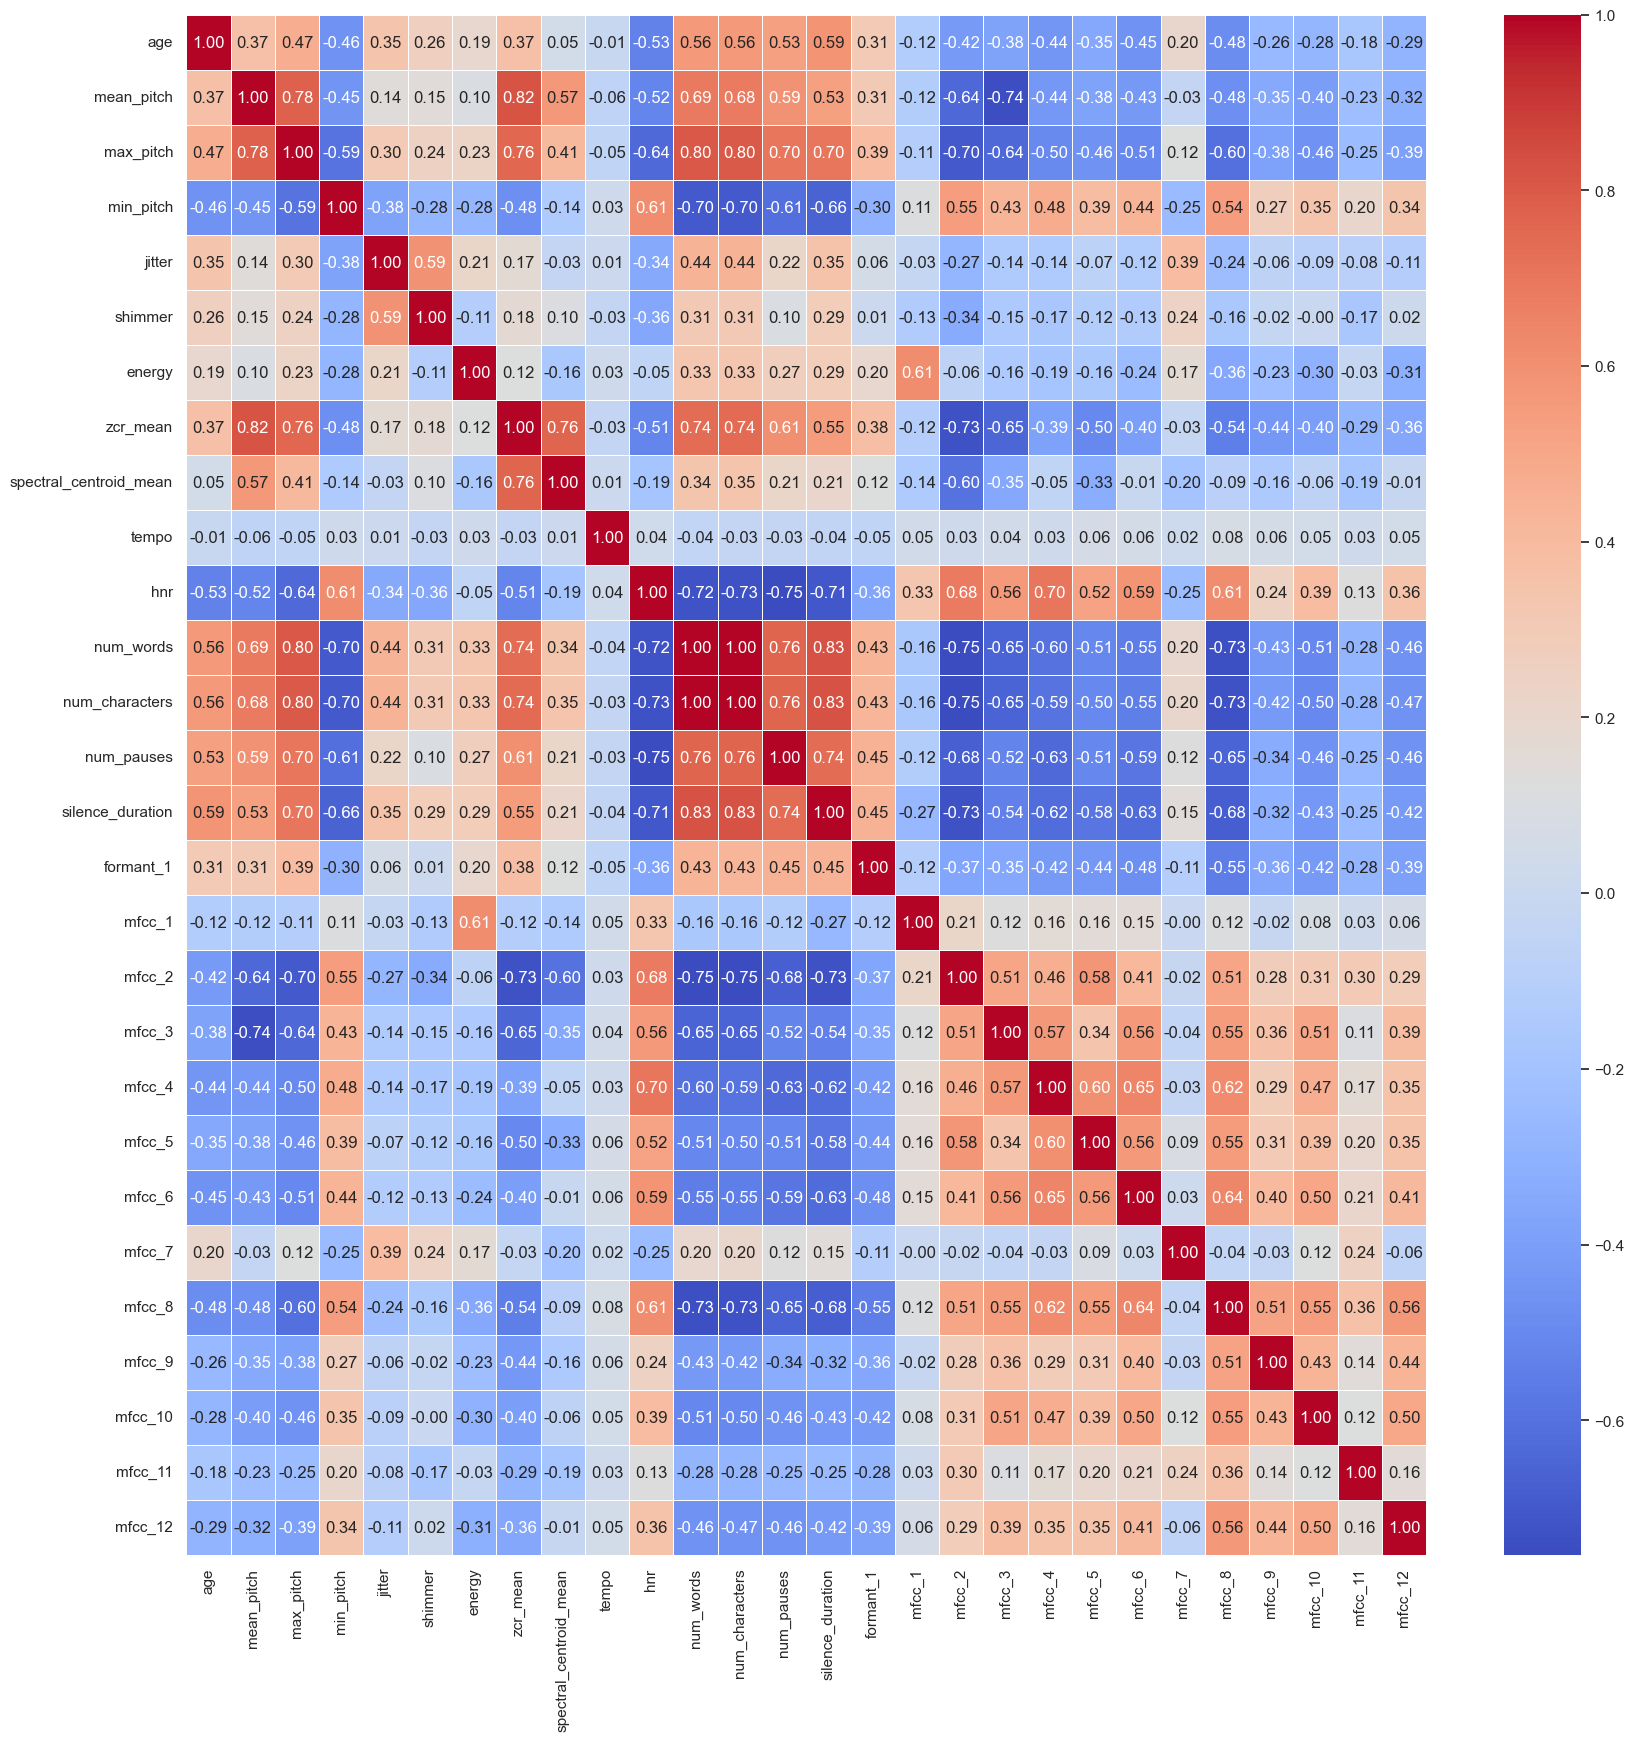

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df_pp_num.corr(method='spearman'),annot=True,linewidths=0.6,fmt=".2f",cmap="coolwarm");

In [ ]:
#The number of characters is highly correlated with the number of words, and the sampling rate is always the same.
#Additionally, since the path and audio ID are no longer useful after extracting the features. All that features will be removed.

df_pp = df_pp.drop(columns=['num_characters','sampling_rate','tempo','path','audio_id'])

 ### **Influence of Gender in Shimmer and Jitter**

In [ ]:
#The gender variable cannot directly influence age, as they are both demographic variables, and such a relationship does not make sense.
#However, gender may influence the values of other variables. An analysis of the relationship between gender and other acoustic variables
#revealed a strong correlation with shimmer and jitter. Below are the plots that demonstrate this relationship.

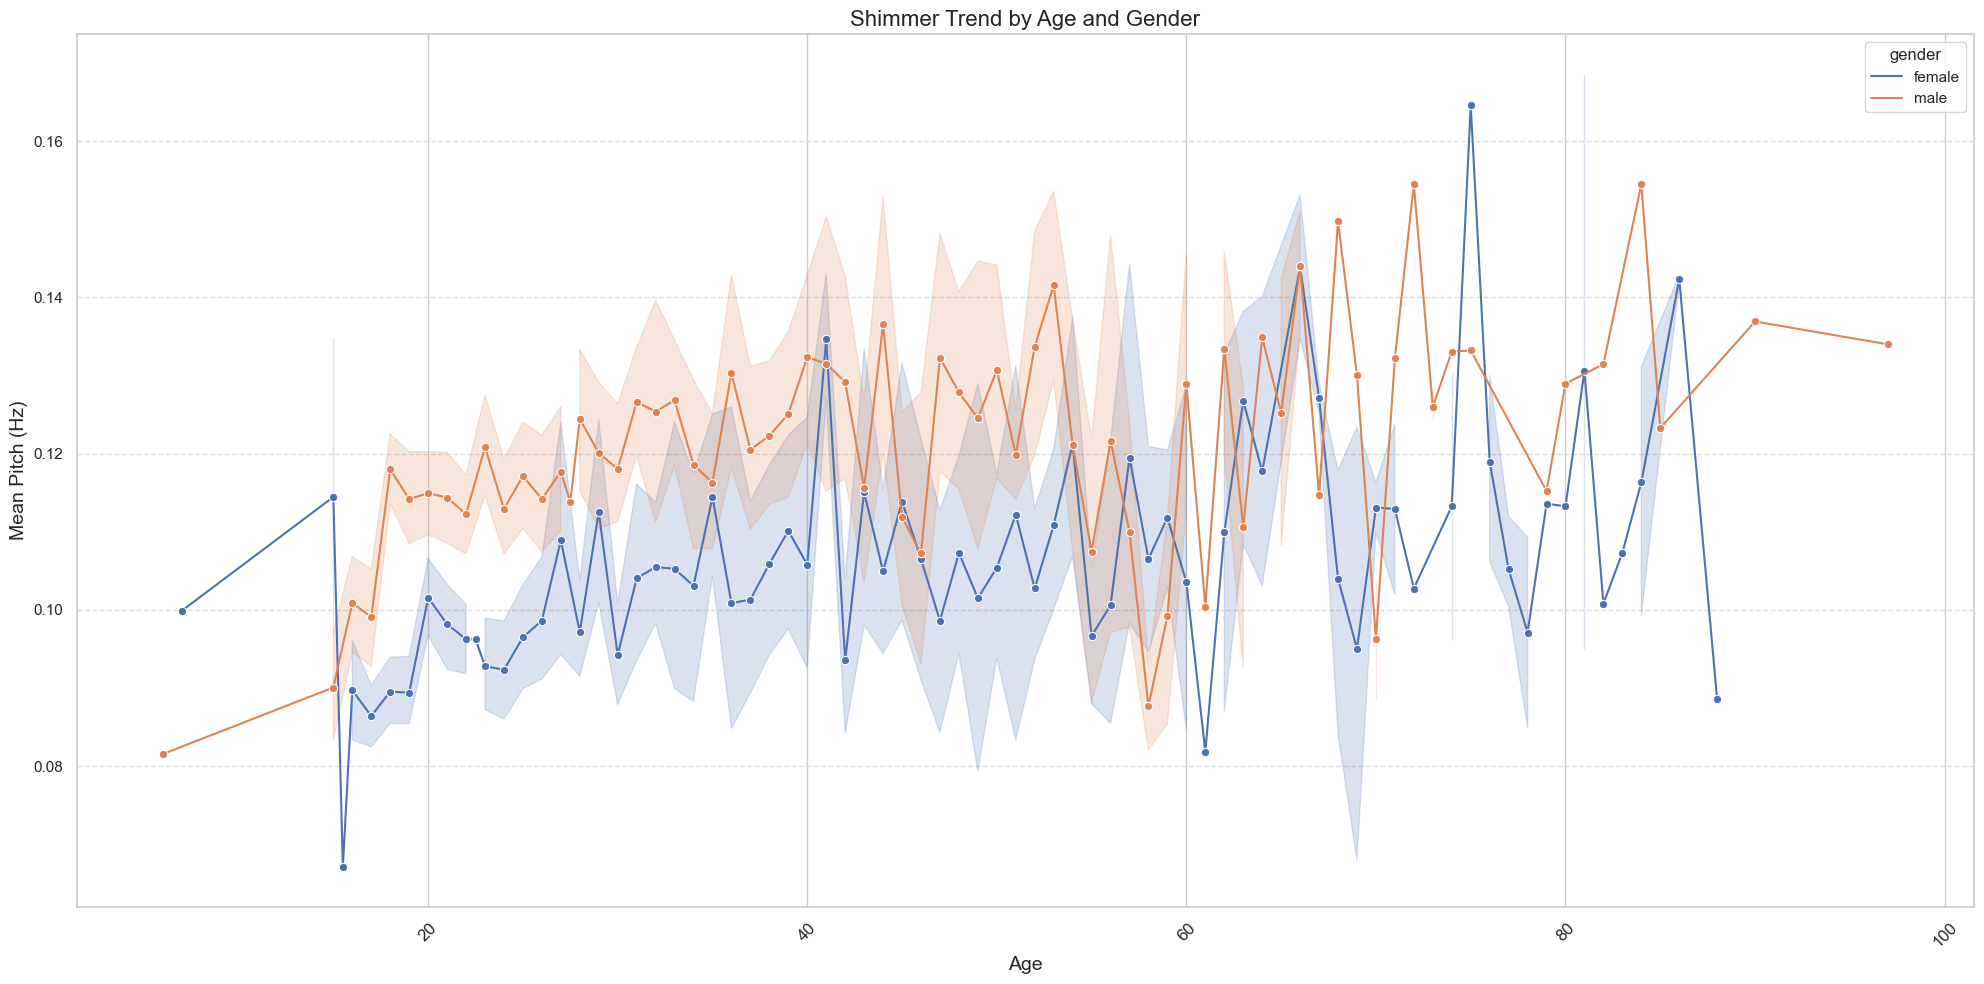

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(data=df_pp, x='age', y='shimmer', hue='gender', marker='o')
plt.title("Shimmer Trend by Age and Gender", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Mean Pitch (Hz)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


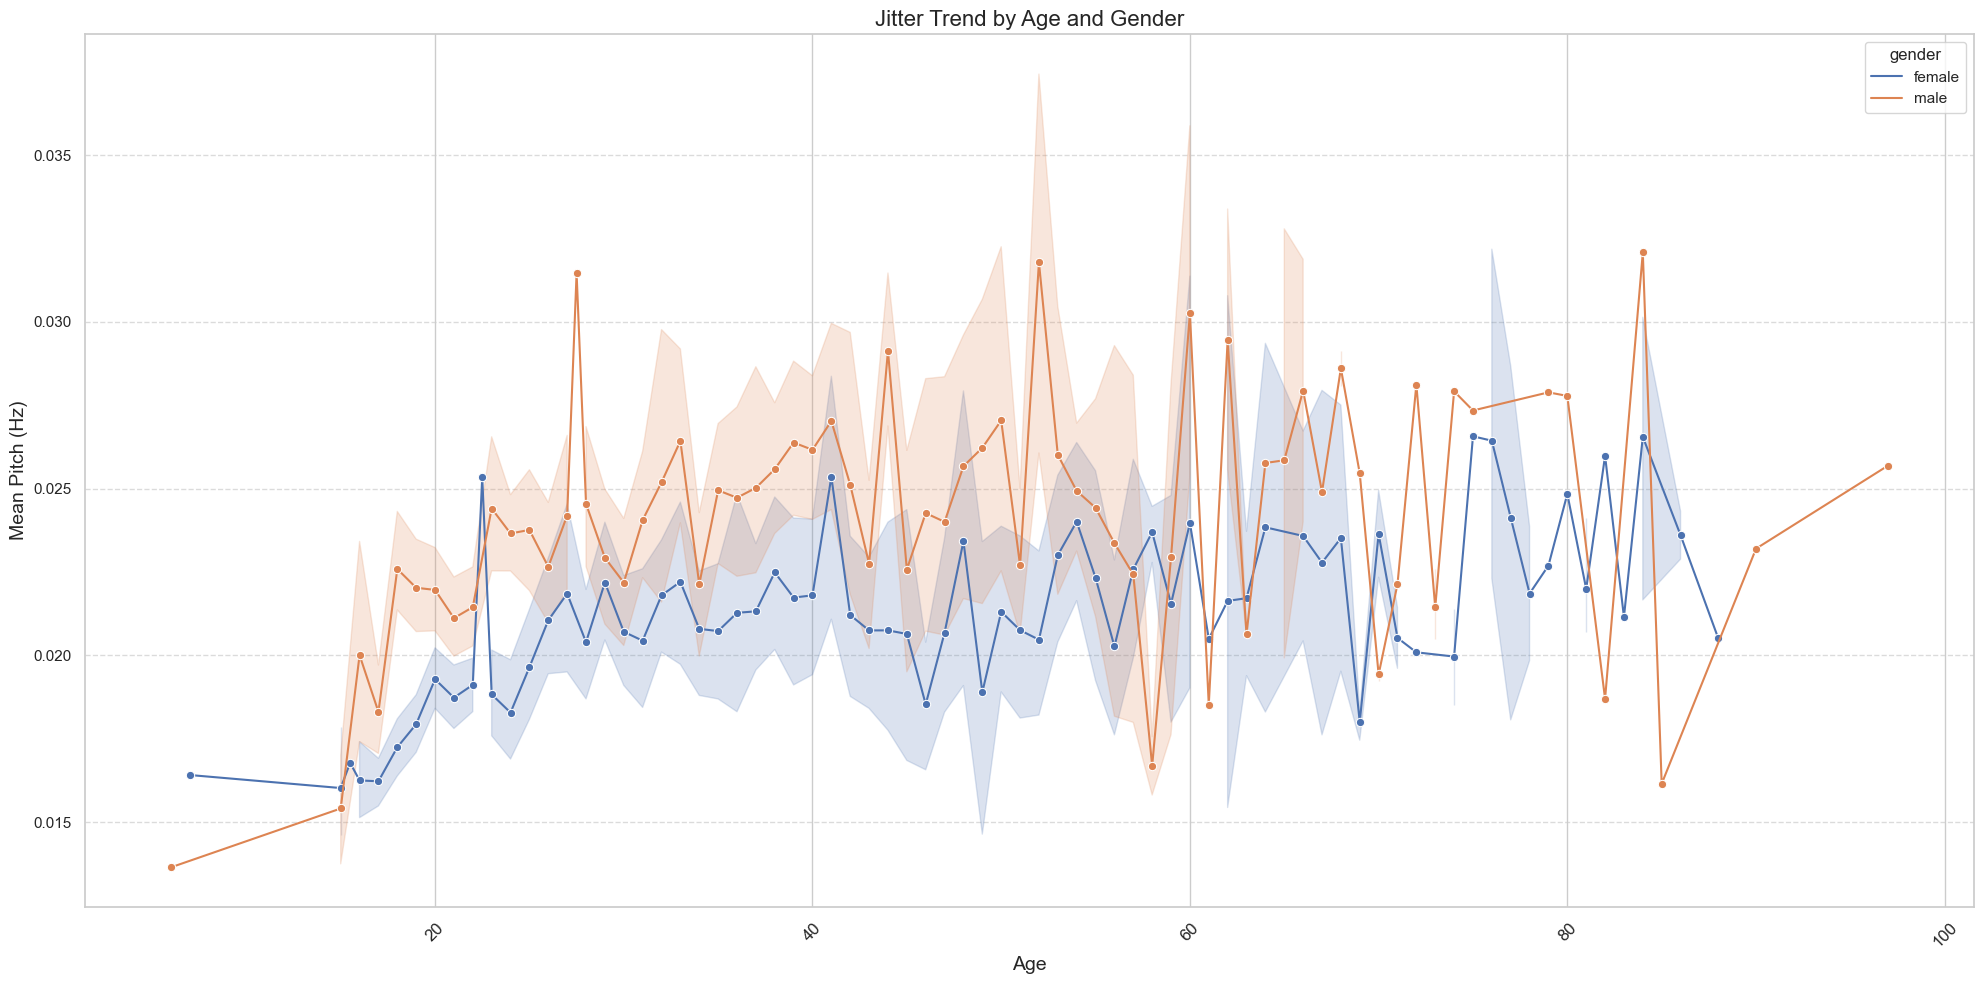

In [ ]:
plt.figure(figsize=(20,10))
sns.lineplot(data=df_pp, x='age', y='jitter', hue='gender', marker='o')
plt.title("Jitter Trend by Age and Gender", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Mean Pitch (Hz)", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
#For this reason, we proceed by dividing the features based on gender.
#We create four new variables and remove the general ones. Additionally, due to the previously mentioned relationship between
#gender and age, the gender variable will also be eliminated.

df_pp['jitter_male'] = np.where(df_pp['gender'] == 'male', df_pp['jitter'], 0)
df_pp['jitter_female'] = np.where(df_pp['gender'] == 'female', df_pp['jitter'], 0)

df_pp['shimmer_male'] = np.where(df_pp['gender'] == 'male', df_pp['shimmer'], 0)
df_pp['shimmer_female'] = np.where(df_pp['gender'] == 'female', df_pp['shimmer'], 0)


df_pp = df_pp.drop(['jitter', 'shimmer', 'gender'], axis=1)

### **FIRST INSPECTION**

In [ ]:
'''
Following the analysis of various feature alternatives, it was determined that the most useful features for further analysis are the following:

- 'mean_pitch',
- 'max_pitch',
- 'min_pitch',
- 'energy',
- 'zcr_mean',
- 'spectral_centroid_mean',
- 'hnr',
- 'num_pauses',
- 'silence_duration',
- 'formant_1',
- 'mfcc_1',
- 'mfcc_2',
- 'mfcc_4',
- 'mfcc_6',
- 'mfcc_8',
- 'mfcc_11',
- 'jitter_male',
- 'jitter_female',
- 'shimmer_male',
- 'shimmer_female'


For this reason, the features 'mfcc_12', 'mfcc_7', 'mfcc_3', 'mfcc_9', 'mfcc_10' and 'mfcc_5' have been removed.

'''

df_pp = df_pp.drop(['mfcc_12', 'mfcc_7', 'mfcc_3', 'mfcc_9', 'mfcc_10',  'mfcc_5'], axis=1)

### **Data Trasformation**

In [ ]:
df_pp_num = df_pp.drop(columns=['continent'])

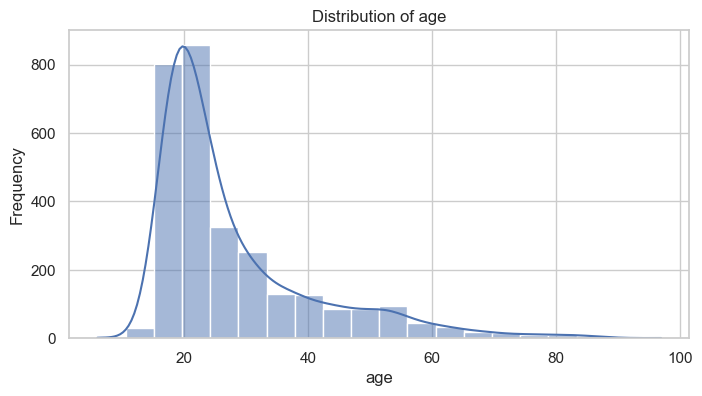

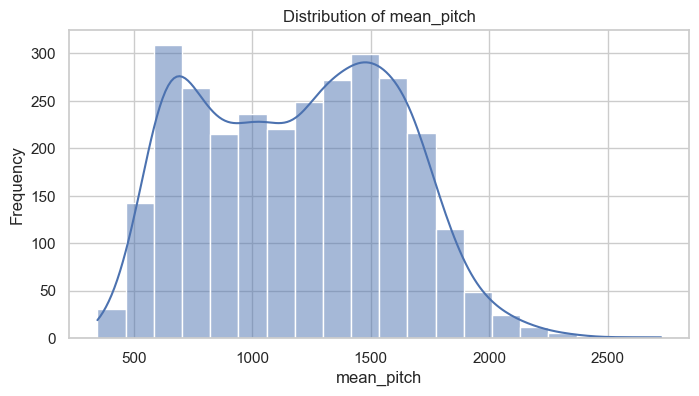

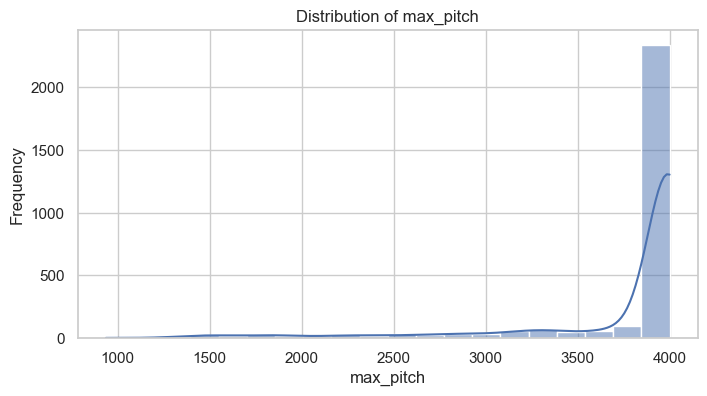

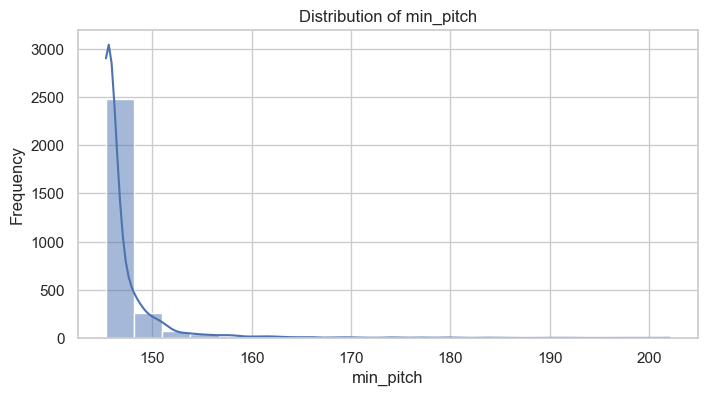

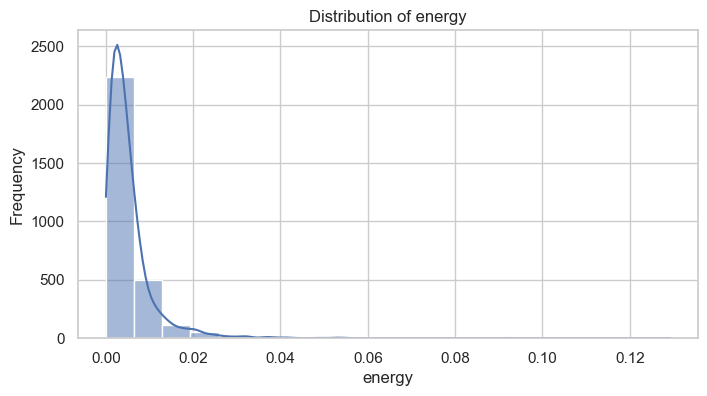

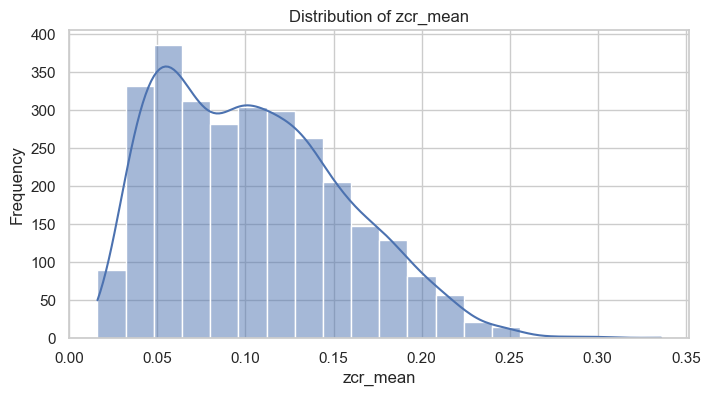

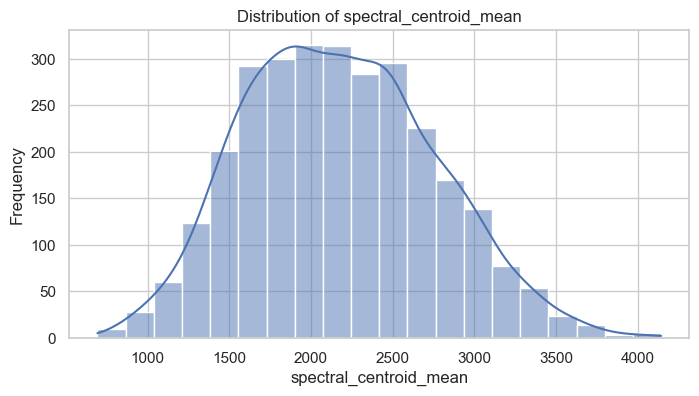

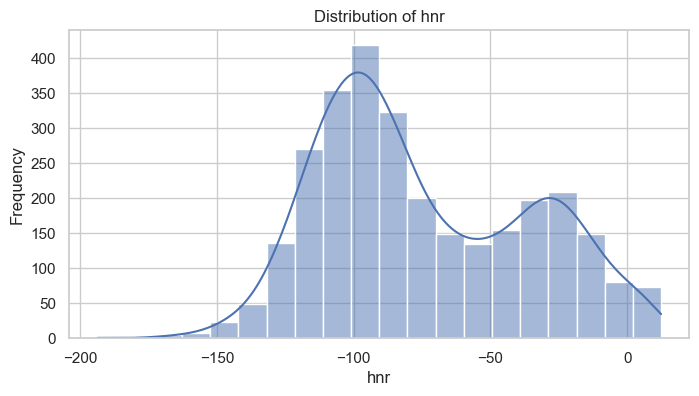

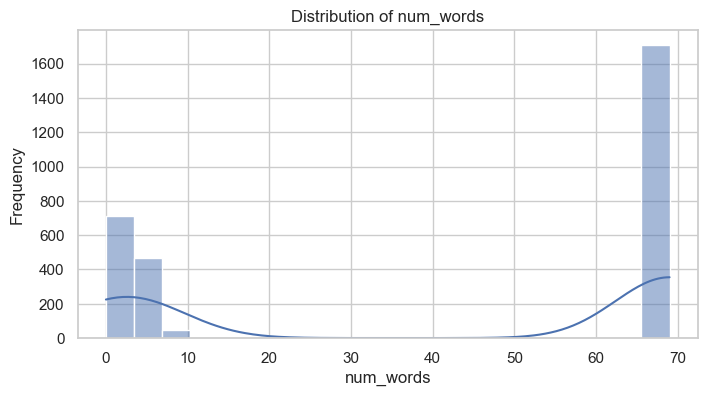

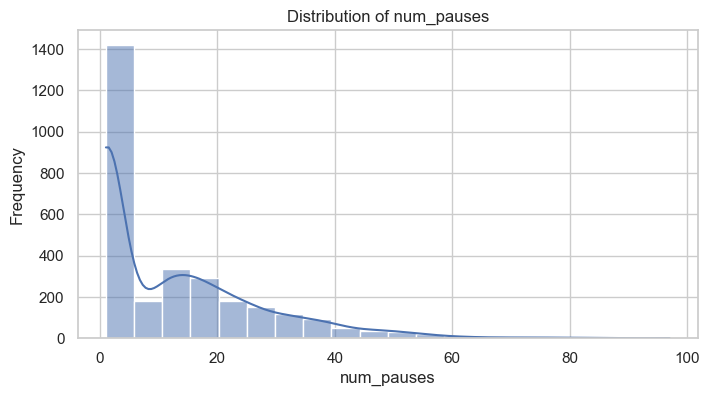

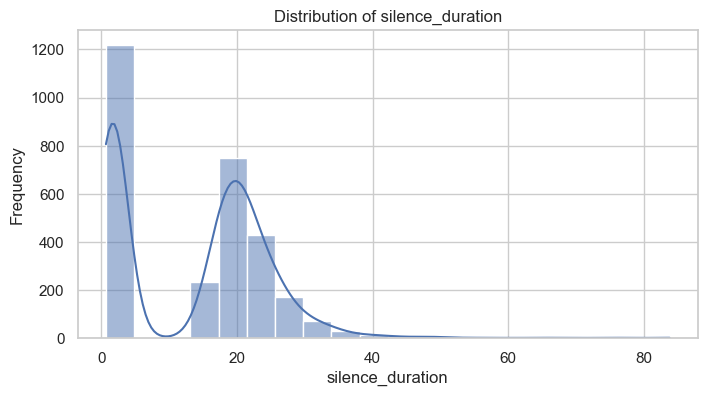

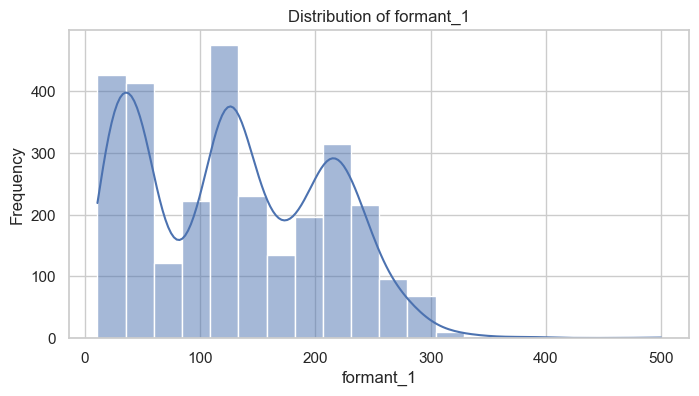

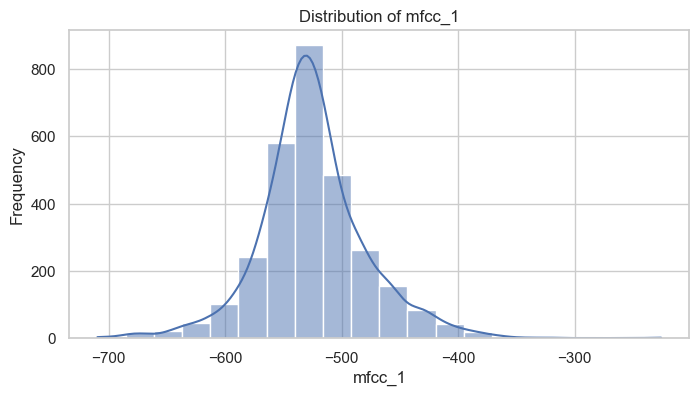

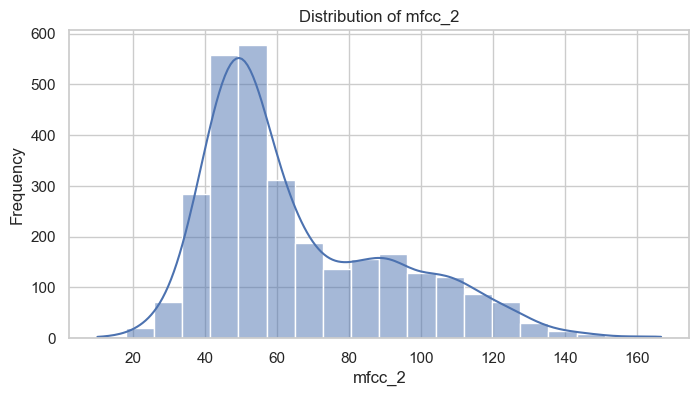

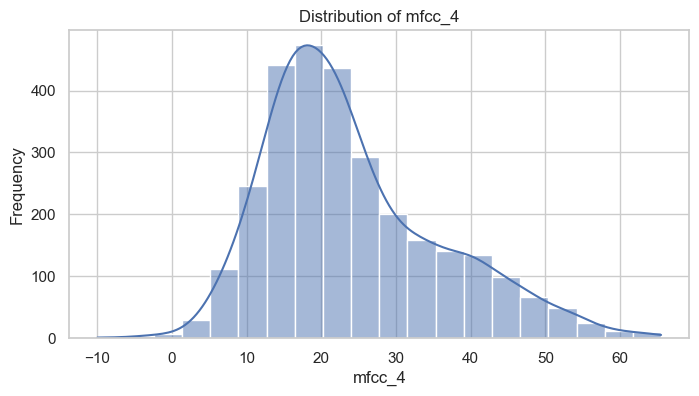

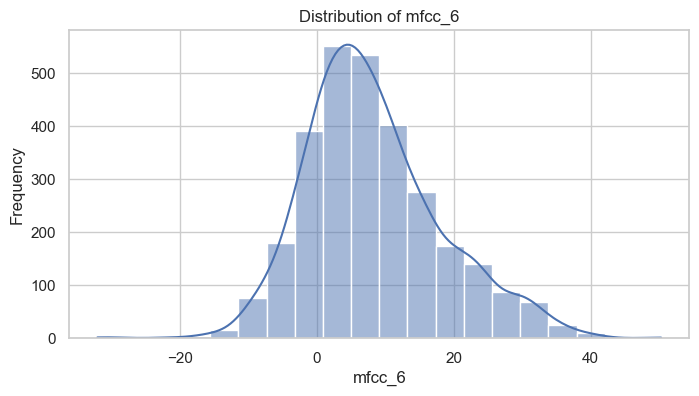

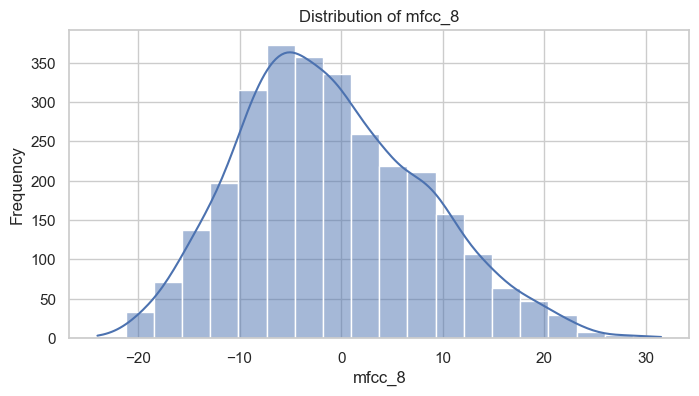

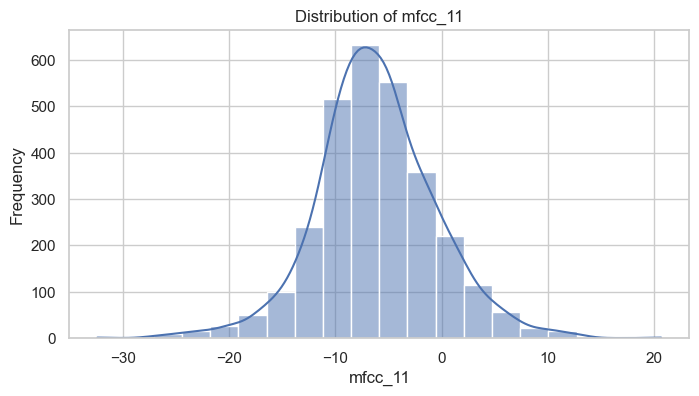

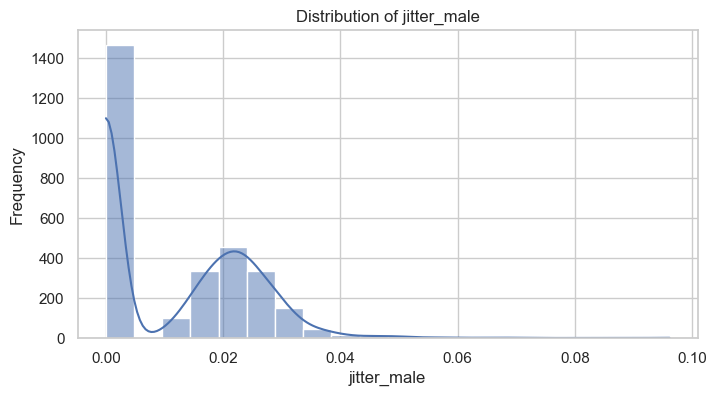

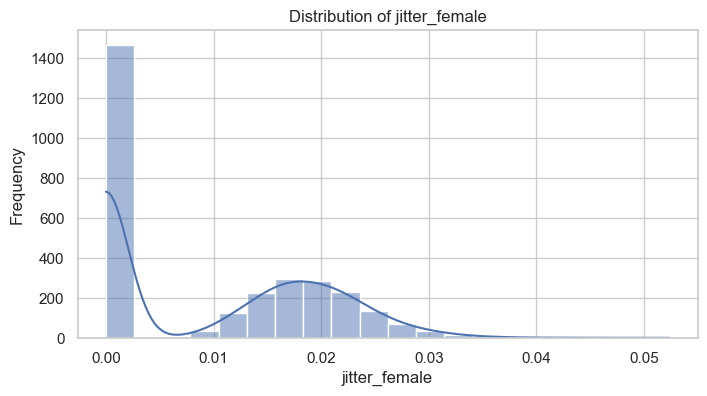

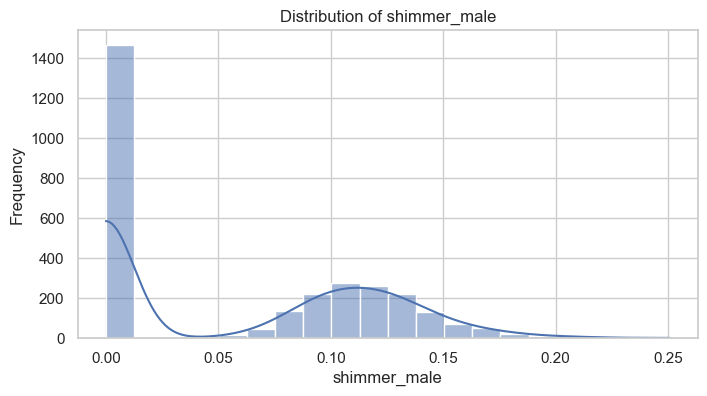

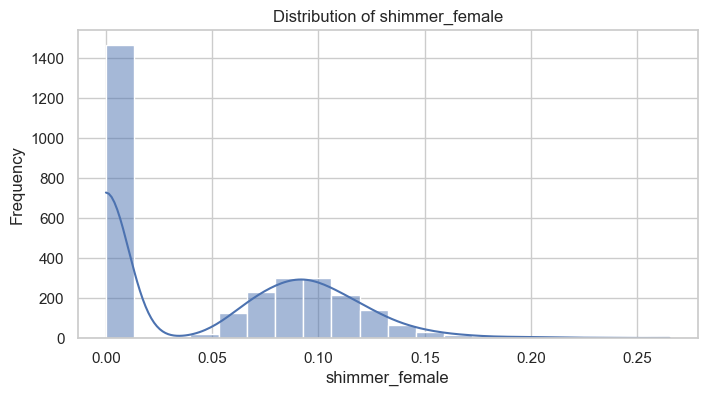

In [ ]:
for col in df_pp_num.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_pp_num[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

In [ ]:
#After analyzing the distributions of the features, specific transformations were applied to enhance both visualization and model performance.
#These transformations included standardization and, where applicable, the Box-Cox transformation.
#The feature representing the number of words was excluded from these adjustments, as it does not follow a defined distribution pattern.

zscore_features = ['max_pitch', 'min_pitch', 'mean_pitch',
                   'energy', 'zcr_mean', 'spectral_centroid_mean',
                   'formant_1', 'mfcc_1', 'mfcc_2', 'mfcc_4',
                   'mfcc_6', 'mfcc_8', 'mfcc_11']

iqr_features = ['hnr', 'silence_duration', 'num_pauses',
                'jitter_male', 'jitter_female', 'shimmer_male', 'shimmer_female']


scaler = StandardScaler()
df_pp[zscore_features] = scaler.fit_transform(df_pp[zscore_features])

#lambda values are memorized to be used in the df_eval
lambda_values = {}
for feature in iqr_features:
    if (df_pp[feature] <= 0).any():
        print(f"Warning: {feature} contains non-positive values. Box-Cox transformation cannot be applied.")
    else:
        df_pp[feature], lambda_val = boxcox(df_pp[feature])
        lambda_values[feature] = lambda_val
        print(f"Applied Box-Cox transformation to {feature} with lambda: {lambda_val}")

Applied Box-Cox transformation to silence_duration with lambda: 0.31160569141159644
Applied Box-Cox transformation to num_pauses with lambda: -0.04519836372550669


Skewness: 1.7915940992126584
Kurtosis: 3.161123046917596


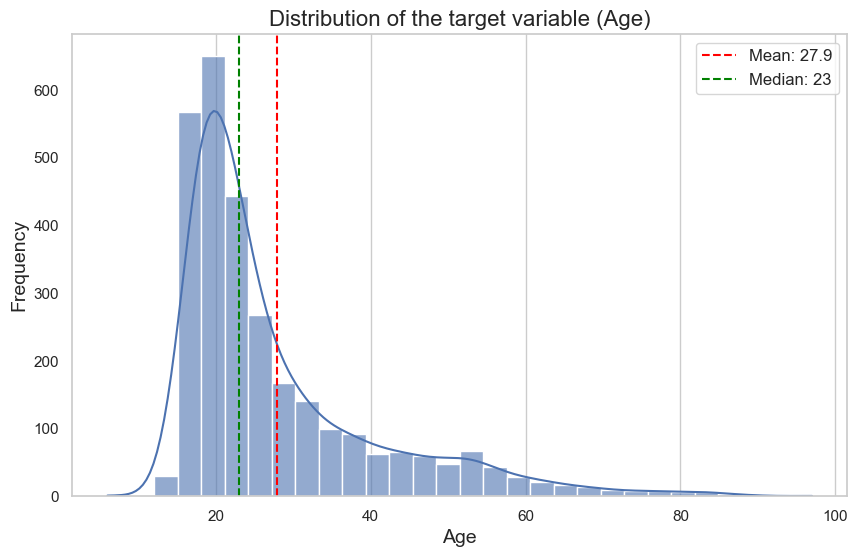

In [ ]:
age_skew=skew(df_pp['age'], axis=0, bias=True)
print(f'Skewness: {age_skew}')
age_kurt=kurtosis(df_pp['age'], axis=0, bias=True)
print(f'Kurtosis: {age_kurt}')


df_dev['age'].describe()

data_statistics = {
    'Mean': 27.9,
    'Median': 23,
}


plt.figure(figsize=(10, 6))
sns.histplot(df_dev['age'], kde=True, bins=30, alpha=0.6)
plt.axvline(data_statistics['Mean'], color='red', linestyle='--', label=f"Mean: {data_statistics['Mean']}")
plt.axvline(data_statistics['Median'], color='green', linestyle='--', label=f"Median: {data_statistics['Median']}")
plt.title('Distribution of the target variable (Age)', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(fontsize=12)
plt.grid(axis='y')
plt.show()

### **Outlier Detection**

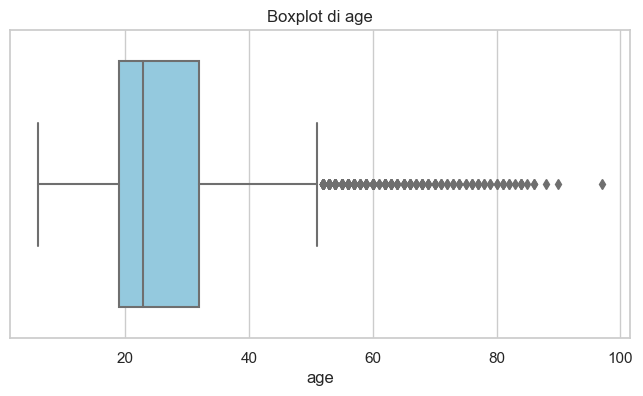

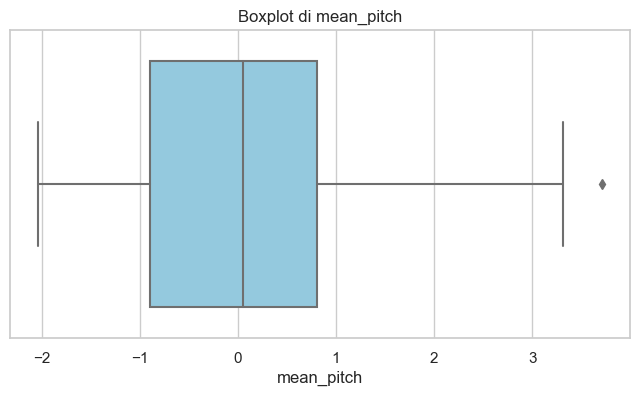

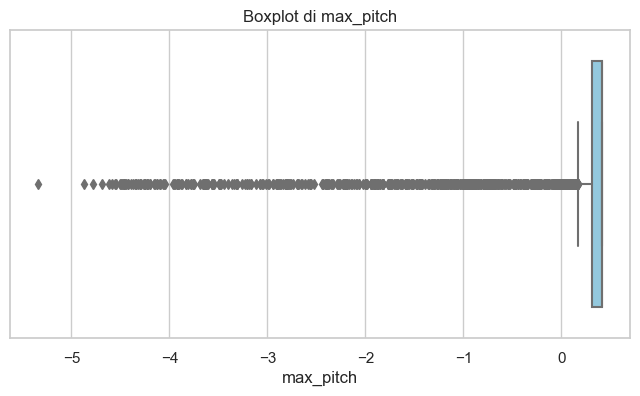

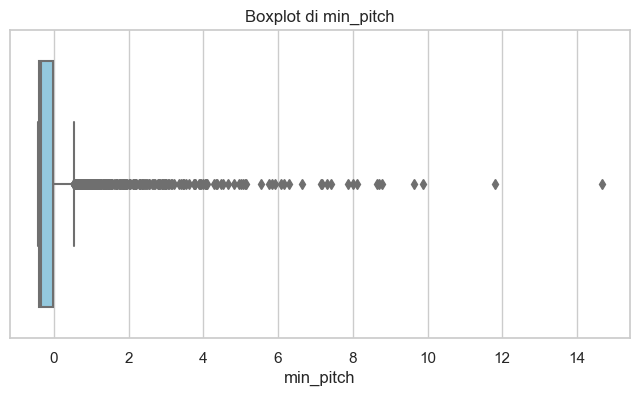

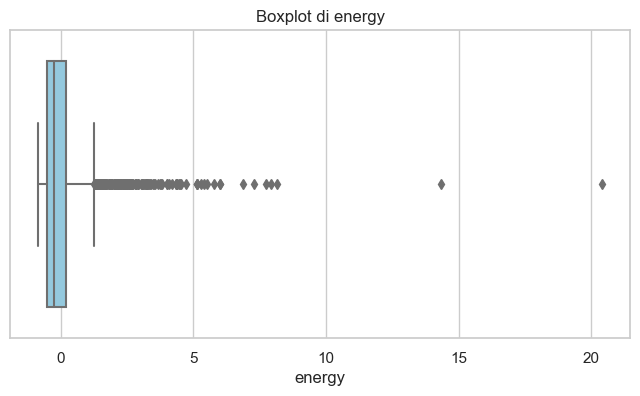

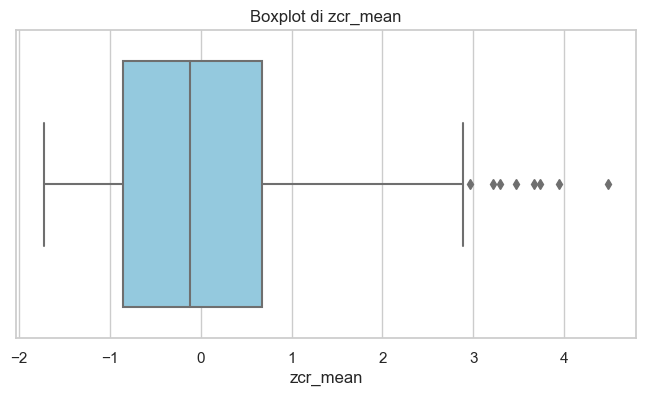

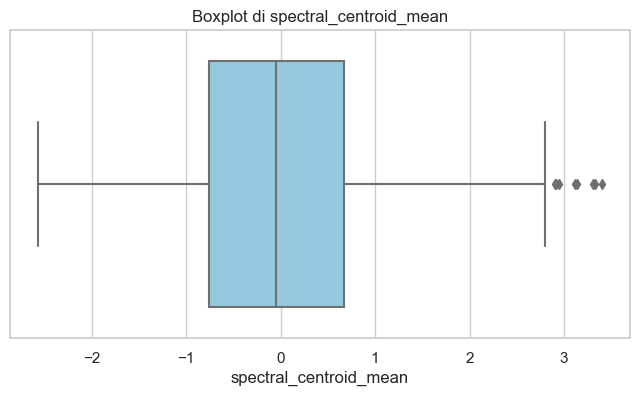

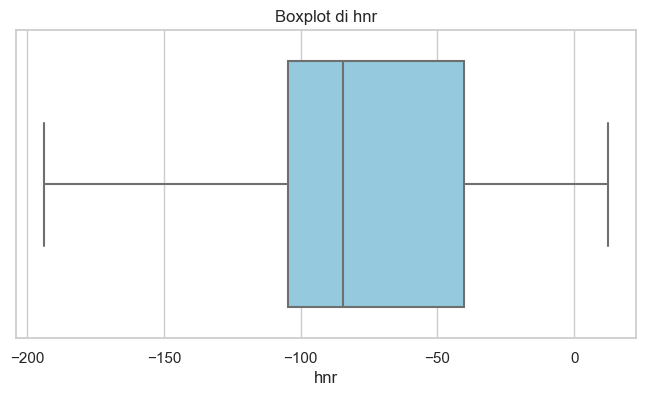

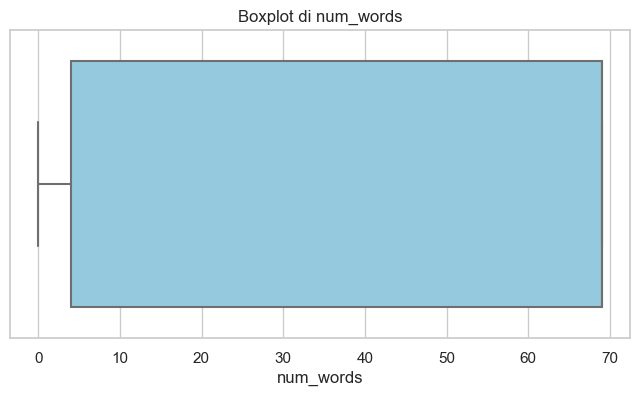

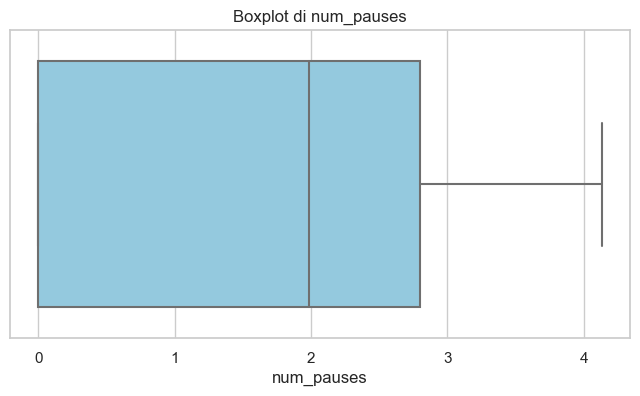

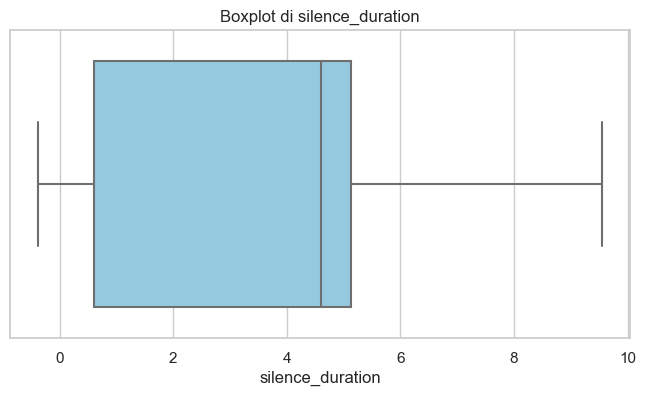

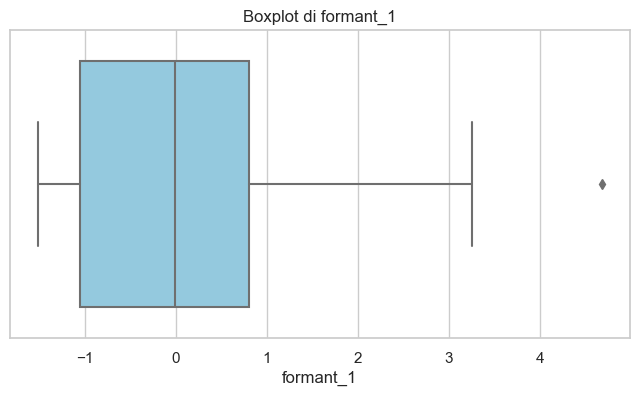

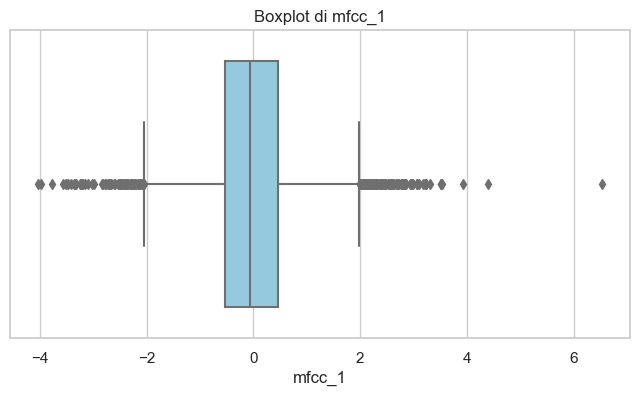

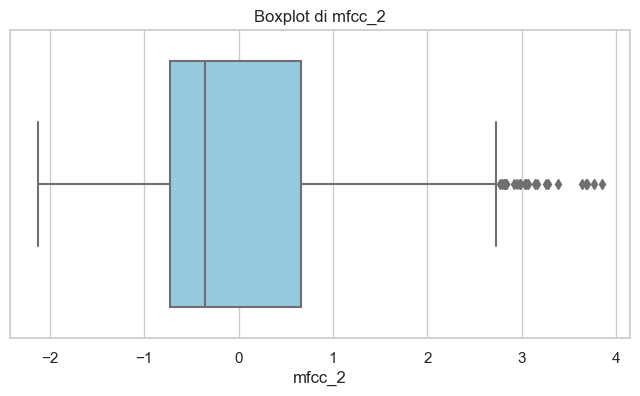

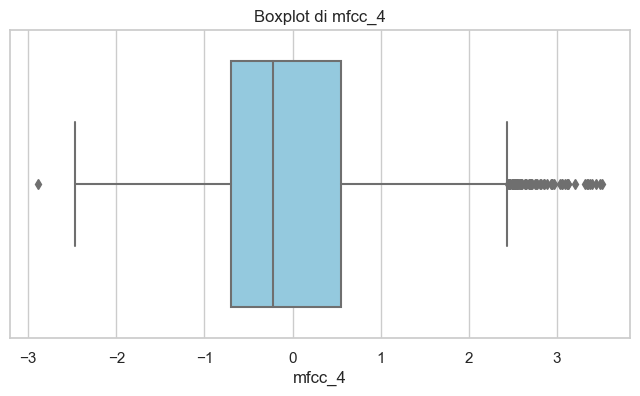

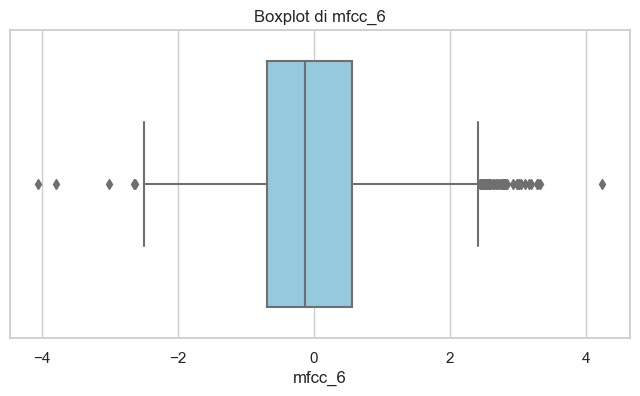

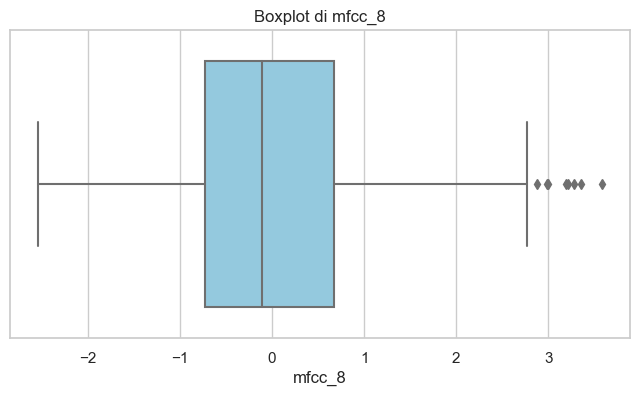

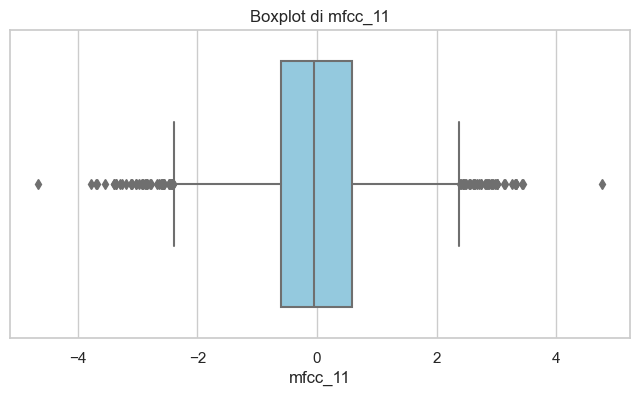

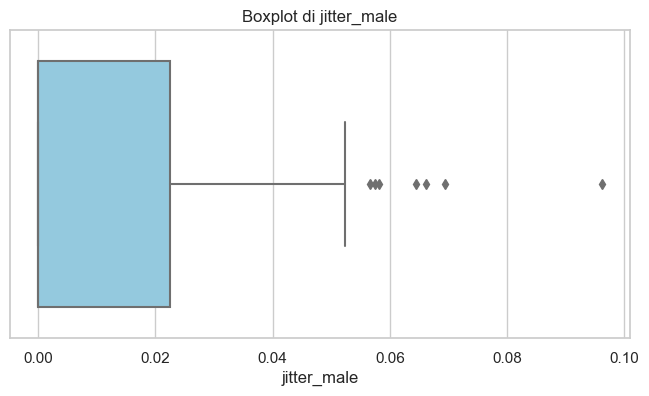

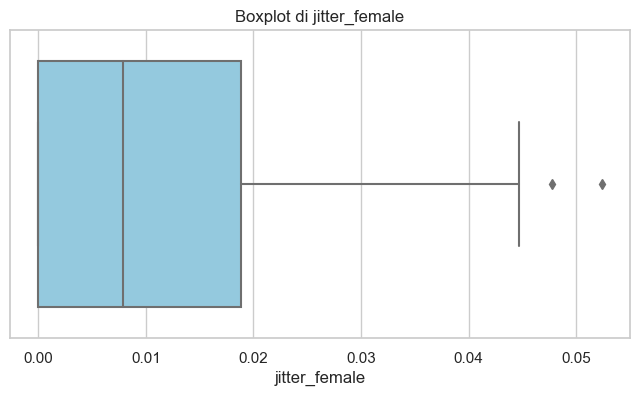

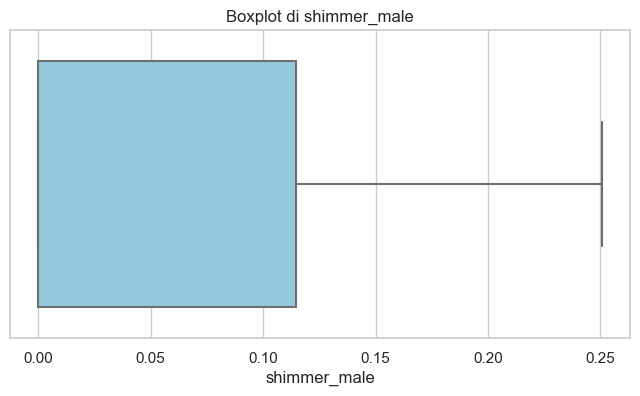

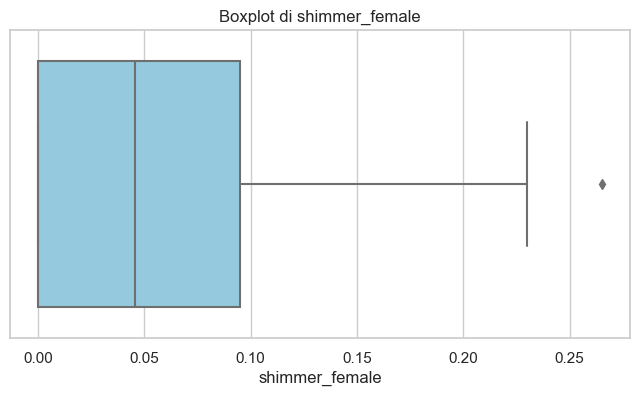

In [ ]:
#Outliers Detection Boxplot
numeric_columns_pp = df_pp.select_dtypes(include=[np.number]).columns
for col in numeric_columns_pp:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_pp[col], color="skyblue")
    plt.title(f"Boxplot di {col}")
    plt.xlabel(col)
    plt.show()


In [ ]:
#Outliers were managed using two different methods based on the specific characteristics of each variable.
# Interquartile Range (IQR): was applied to variables with skewed distributions to identify and treat values outside the defined range.
# Z-score Method: for variables with distributions closer to normal, we used the Z-score method to classify as outliers those exceeding
#a specified threshold.

def remove_outliers_mixed(df, zscore_features, iqr_features, zscore_threshold=3, iqr_threshold=2):
    df_cleaned = df.copy()
    if zscore_features:
        z = np.abs(stats.zscore(df_cleaned[zscore_features]))
        df_cleaned = df_cleaned[(z < zscore_threshold).all(axis=1)]
    if iqr_features:
        Q1 = df_cleaned[iqr_features].quantile(0.25)
        Q3 = df_cleaned[iqr_features].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - iqr_threshold * IQR
        upper_bound = Q3 + iqr_threshold * IQR
        df_cleaned = df_cleaned[((df_cleaned[iqr_features] >= lower_bound) & (df_cleaned[iqr_features] <= upper_bound)).all(axis=1)]
    return df_cleaned


In [ ]:
iqr_features.append('age')
df_pp = remove_outliers_mixed(df_pp, zscore_features, iqr_features)


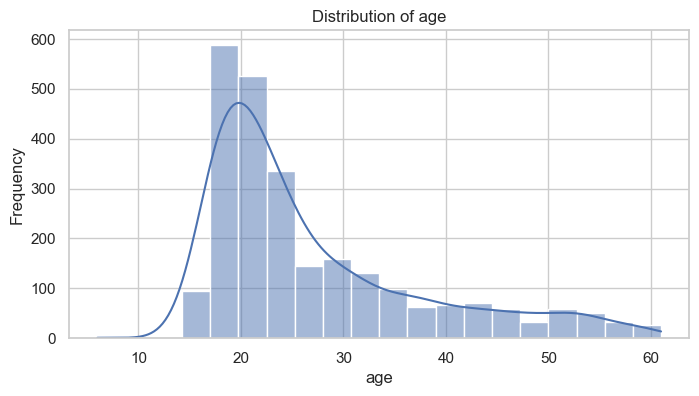

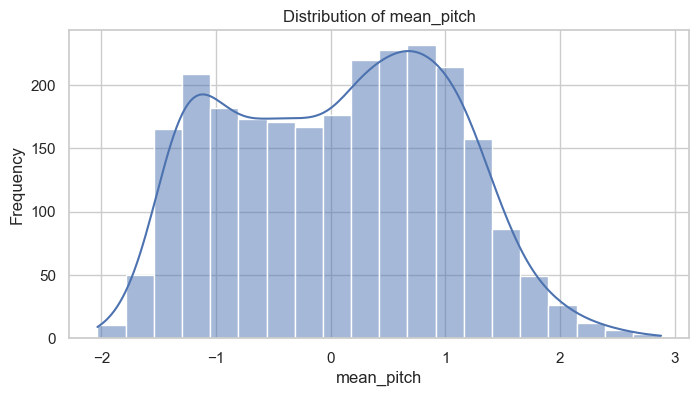

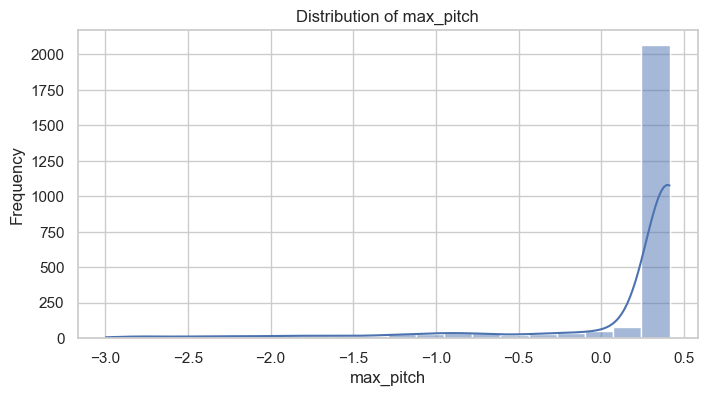

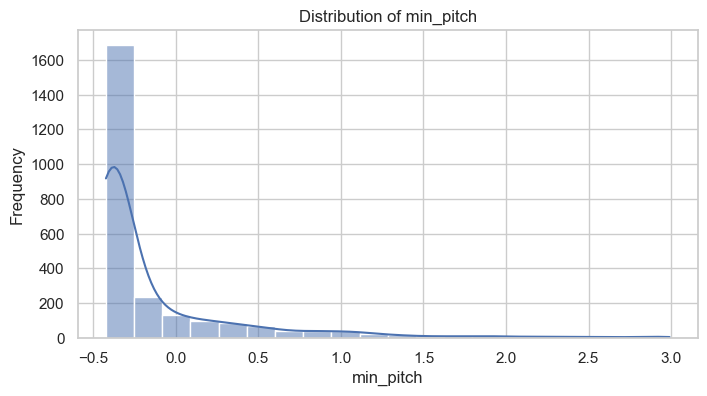

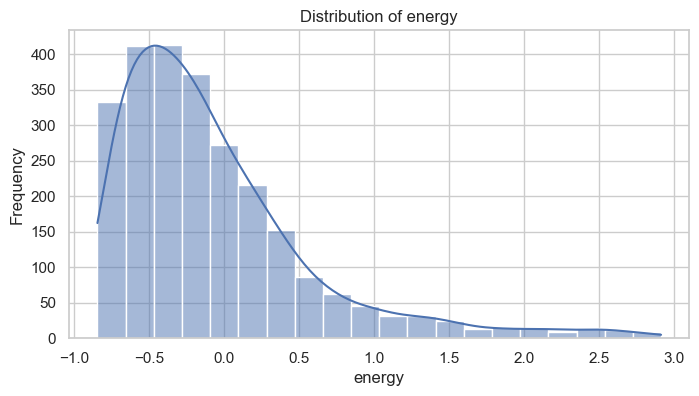

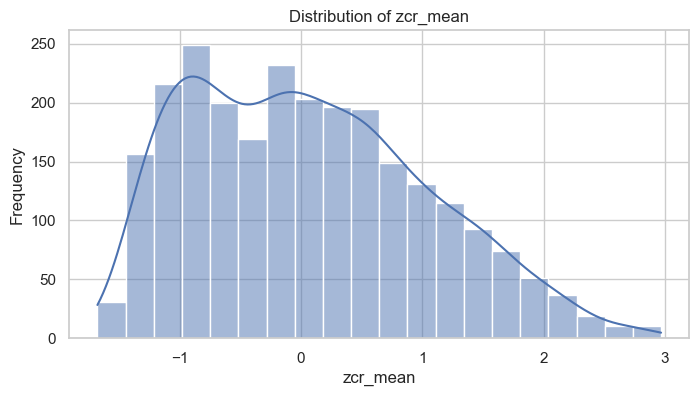

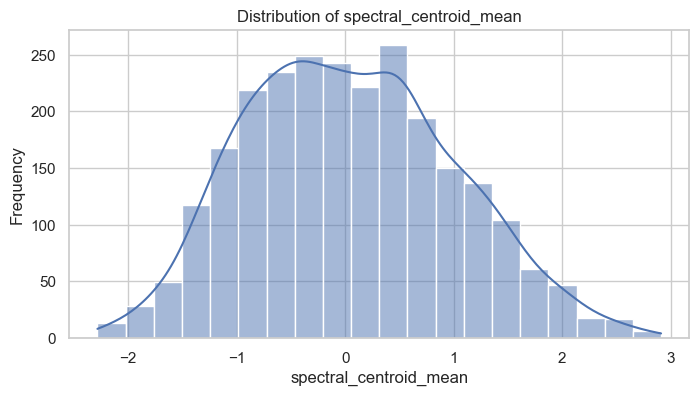

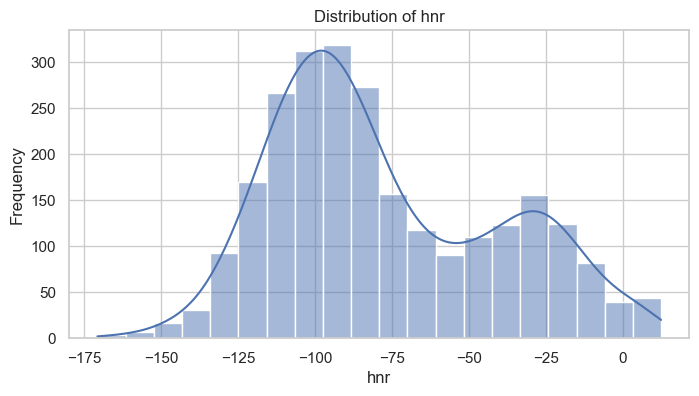

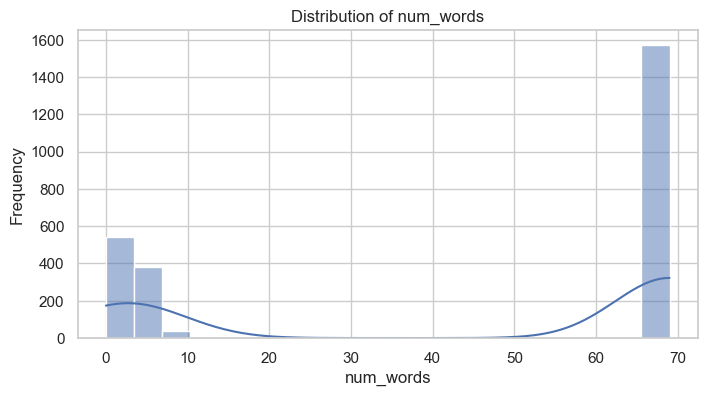

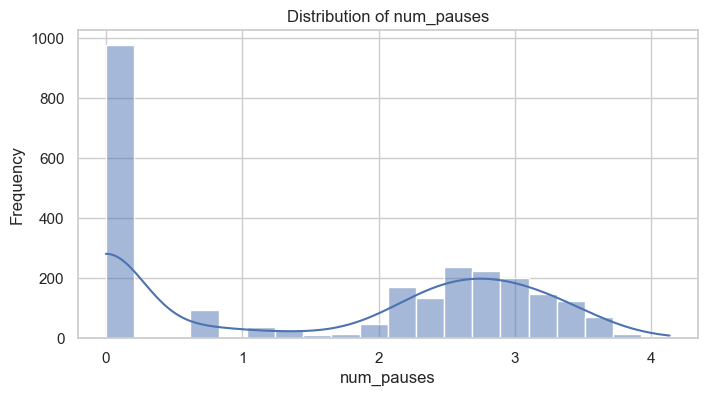

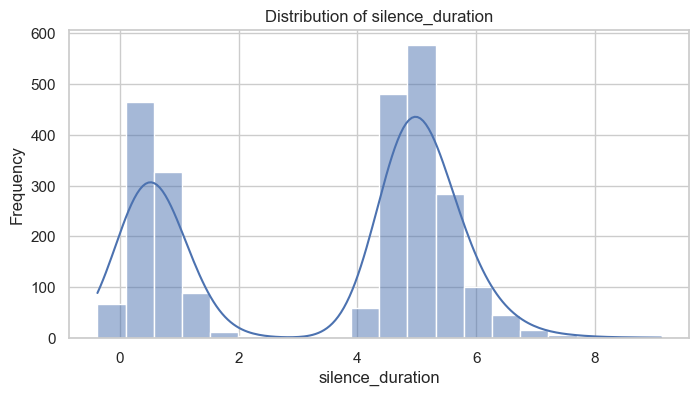

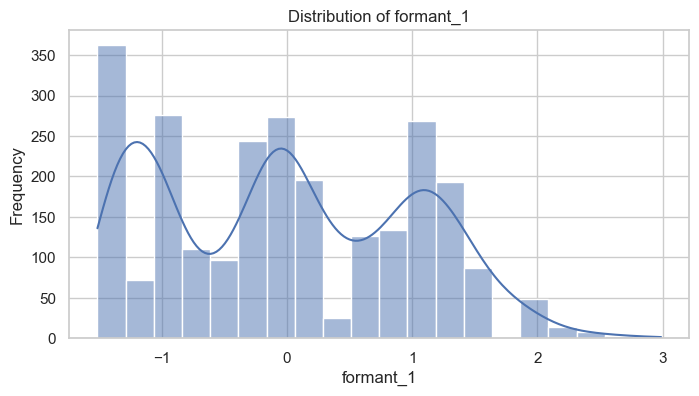

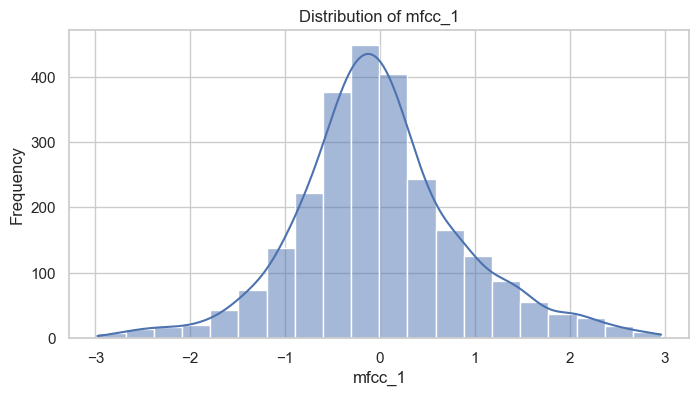

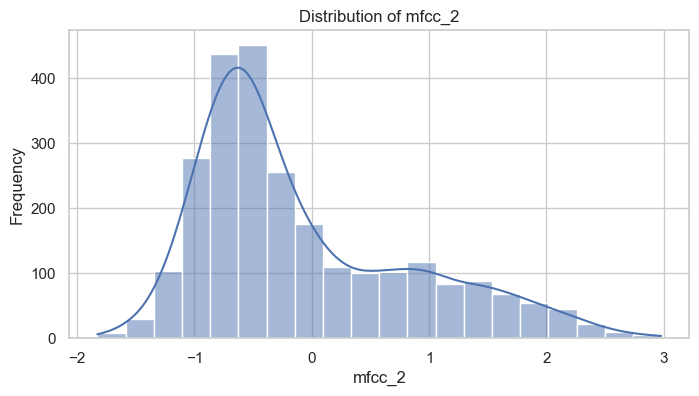

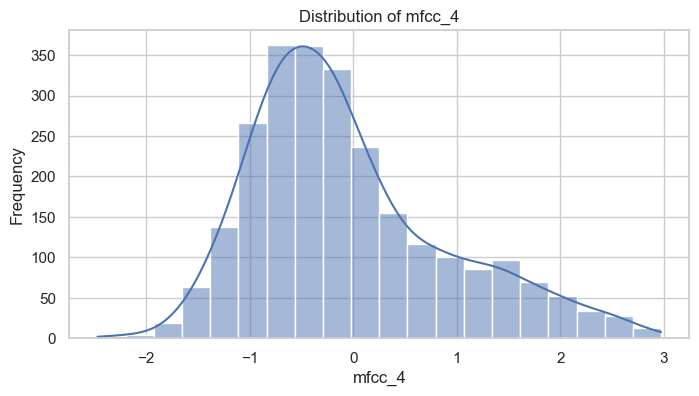

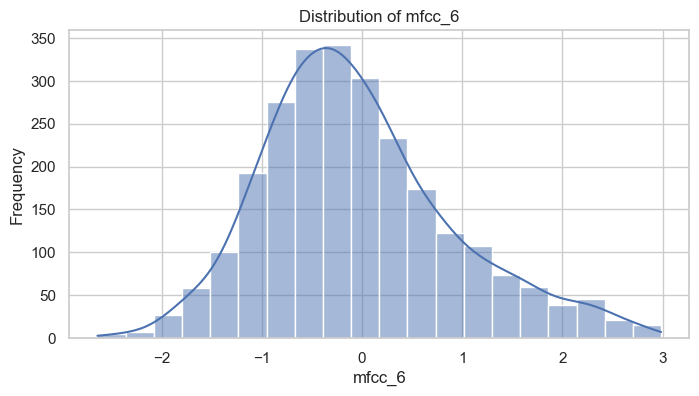

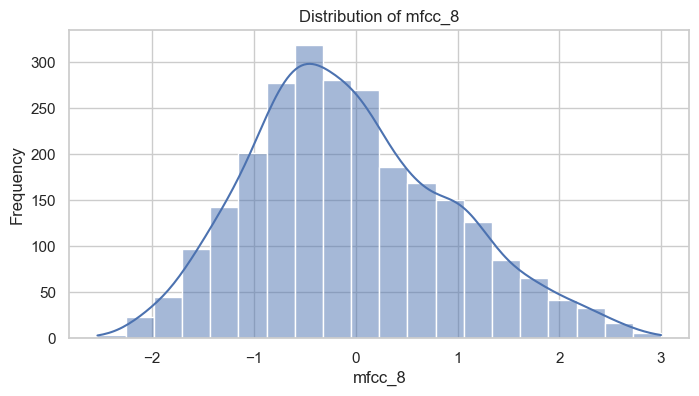

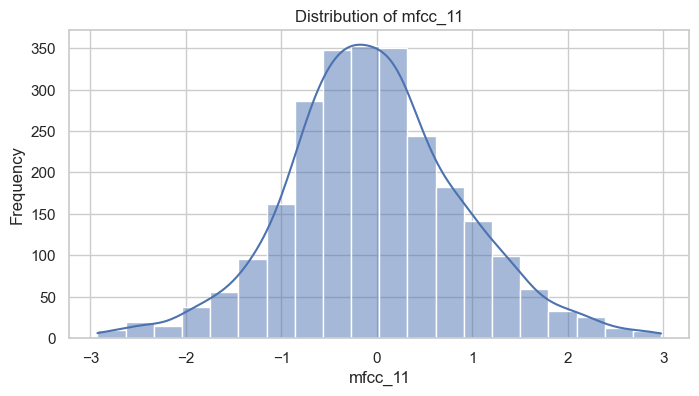

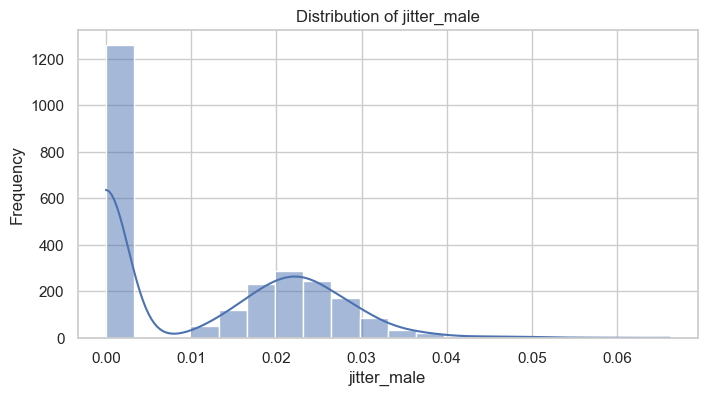

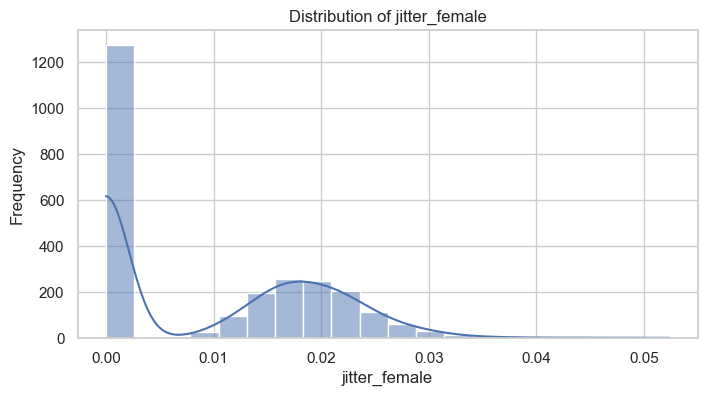

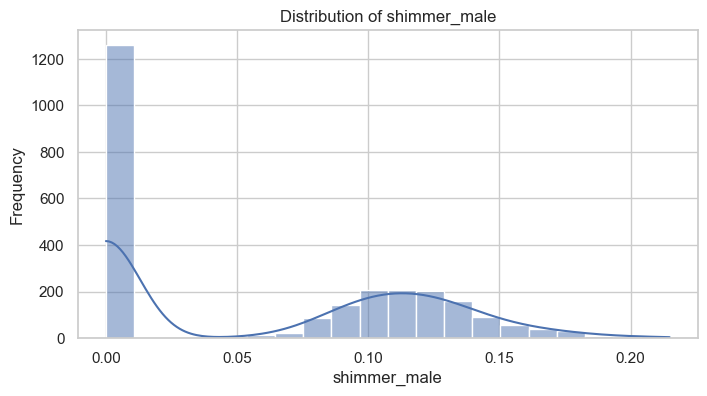

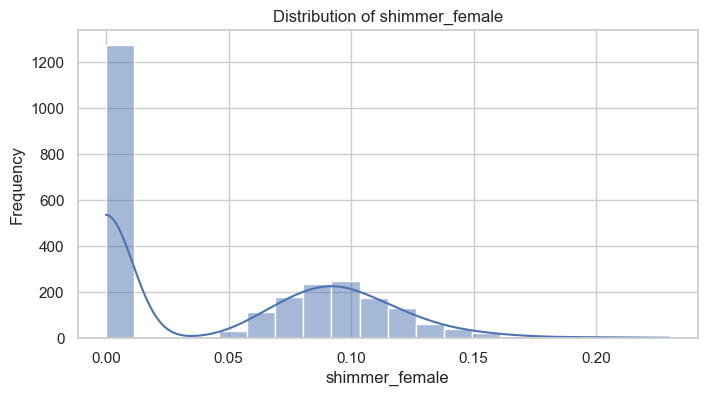

In [ ]:
df_pp_num = df_pp.drop(columns=['continent'])
for col in df_pp_num.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_pp_num[col], kde=True, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

In [ ]:
#At this point, the only remaining categorical variable is the "continent." Therefore, we proceed with a dummy encoding for this variable.

df_pp = pd.get_dummies(df_pp, columns=['continent'],drop_first=True)

In [ ]:
df_endpreprocessing=df_pp

## TRAINING MODEL

In [ ]:
# We added, as the last code cell before the evaluation paragraph, the implementation of the final model
# with the optimazed combination of hyperparameters and all the features added with respect to the observation of the previous models
# This cell can be executed immediately after the preprocessing phase without the need to run the earlier cells, which contains
# the intermediate models that led to this final one

In [ ]:
#In the first part, we aim to determine which regression model best fits our data. This involves testing multiple regression algorithms,
#comparing their performance metrics, and identifying the model that provides the best results for our specific dataset and problem.
#We apply an initial phase of hyperparameter tuning to all three models to identify the best selection of parameters for each.

In [ ]:
df_pp=df_endpreprocessing
y1 = df_pp['age']
X1 = df_pp.drop(['age'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)
models = {
    'Linear Regression': (LinearRegression(), {}),
    'Random Forest': (RandomForestRegressor(), {
        'n_estimators': [10, 50, 100],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }),
    'Support Vector Regression': (SVR(), {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf'],
        'gamma': ['scale', 'auto']
    })
}

results = {}

for name, (model, params) in models.items():
    grid_search = GridSearchCV(model, params, scoring='neg_mean_squared_error', cv=5)
    grid_search.fit(X_train, y_train)
    y_pred = grid_search.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Salvataggio dei risultati
    results[name] = {
        'Best Parameters': grid_search.best_params_,
        'R²': r2,
        'RMSE': rmse
    }

results_df = pd.DataFrame(results).T
display(results_df)


In [ ]:
#From these initial attempts, we find that the Support Vector Regression (SVR) model can be excluded from our analysis.
#We will proceed only with Linear Regression and Random Forest models. Next, we will analyze in greater detail the
#variables highlighted as significant by the Linear Regression model.

In [ ]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
coefficients = linear_model.coef_
feature_importance = pd.DataFrame({
    'Feature': X1.columns,
    'Coefficient': coefficients
})

feature_importance['Absolute Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='Absolute Coefficient', ascending=False)
print("Feature Importance (Coefficients):")
print(feature_importance[['Feature', 'Coefficient', 'Absolute Coefficient']])


Feature Importance (Coefficients):
                    Feature  Coefficient  Absolute Coefficient
17              jitter_male   204.859365            204.859365
18            jitter_female   135.770346            135.770346
20           shimmer_female    19.525067             19.525067
25  continent_South America    18.311475             18.311475
23  continent_North America   -10.646554             10.646554
9          silence_duration     4.282546              4.282546
24        continent_Oceania     3.064458              3.064458
21           continent_Asia    -3.060772              3.060772
19             shimmer_male    -2.487331              2.487331
22         continent_Europe    -1.979975              1.979975
5    spectral_centroid_mean    -1.801618              1.801618
8                num_pauses     1.755757              1.755757
4                  zcr_mean     1.470798              1.470798
3                    energy    -1.430586              1.430586
11                  

In [ ]:
#Linear Regression focuses primarily on gender (which is dependent on shimmer and jitter) and ethnicity (represented by the continent).
#However, in both cases, these are not parameters that can genuinely help us determine age, as there is no fundamental relationship
#between them and the target variable. Therefore, we will continue the analysis using the Random Forest model.

best_params_rf = results_df.loc['Random Forest', 'Best Parameters']
print("Best Parameters for Random Forest:")
print(best_params_rf)

R-quadro: 0.318765671821792
NMSE: -78.06284305939451
Root Mean Squared Error (MSE) su X_test: 8.783404301864572
RMSE on training data: 5.00
RMSE on test data: 8.78
The model may be suffering from overfitting.
Length of feature_names: 26
Length of feature_importances: 26
                    Feature  Importance
9          silence_duration    0.360822
6                       hnr    0.061453
16                  mfcc_11    0.054765
15                   mfcc_8    0.043038
8                num_pauses    0.041619
14                   mfcc_6    0.041250
5    spectral_centroid_mean    0.039498
13                   mfcc_4    0.034383
12                   mfcc_2    0.033407
0                mean_pitch    0.032931
1                 max_pitch    0.031894
17              jitter_male    0.030204
2                 min_pitch    0.030017
11                   mfcc_1    0.028881
4                  zcr_mean    0.027918
3                    energy    0.026117
20           shimmer_female    0.024154
18       

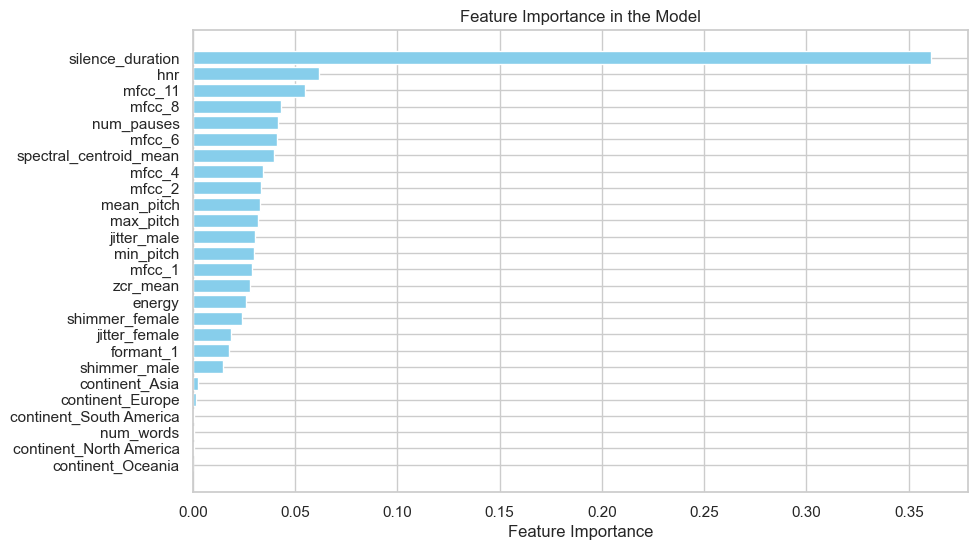

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.6, random_state=2529)

kf = KFold(n_splits=10, shuffle=True, random_state=2529)
rf_model1 = RandomForestRegressor(
    max_depth=10,
    min_samples_split=5,
    n_estimators=100
)

scores_r2 = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()
scores_nmse = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()
print(f"R-squared: {rquadro}")
print(f"NMSE: {NMSE}")
rf_model1.fit(X_train, y_train)
y_pred = rf_model1.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) su X_test: {np.sqrt(mse)}')
y_train_pred = rf_model1.predict(X_train)
y_test_pred = rf_model1.predict(X_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")


if test_rmse - train_rmse > 0.1 * train_rmse:
    print("The model may be suffering from overfitting.")
else:
    print("The model appears to generalize well.")


feature_importances = rf_model1.feature_importances_
print(f"Length of feature_names: {len(X1.columns)}")
print(f"Length of feature_importances: {len(feature_importances)}")

importance_df = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in the Model')
plt.gca().invert_yaxis()
plt.show()


R-squared: 0.31390834717031124
NMSE: -78.98467400560891
Root Mean Squared Error (MSE) on X_test: 8.744926325793843
RMSE on training data: 8.22
RMSE on test data: 8.74
The model appears to generalize well.
Length of feature_names: 26
Length of feature_importances: 26
                    Feature  Importance
9          silence_duration    0.302233
7                 num_words    0.208570
8                num_pauses    0.097173
6                       hnr    0.087231
16                  mfcc_11    0.041207
14                   mfcc_6    0.034095
5    spectral_centroid_mean    0.031456
15                   mfcc_8    0.030540
1                 max_pitch    0.025535
17              jitter_male    0.017482
12                   mfcc_2    0.017168
20           shimmer_female    0.015399
13                   mfcc_4    0.013564
4                  zcr_mean    0.013534
0                mean_pitch    0.011733
18            jitter_female    0.011585
3                    energy    0.011405
2            

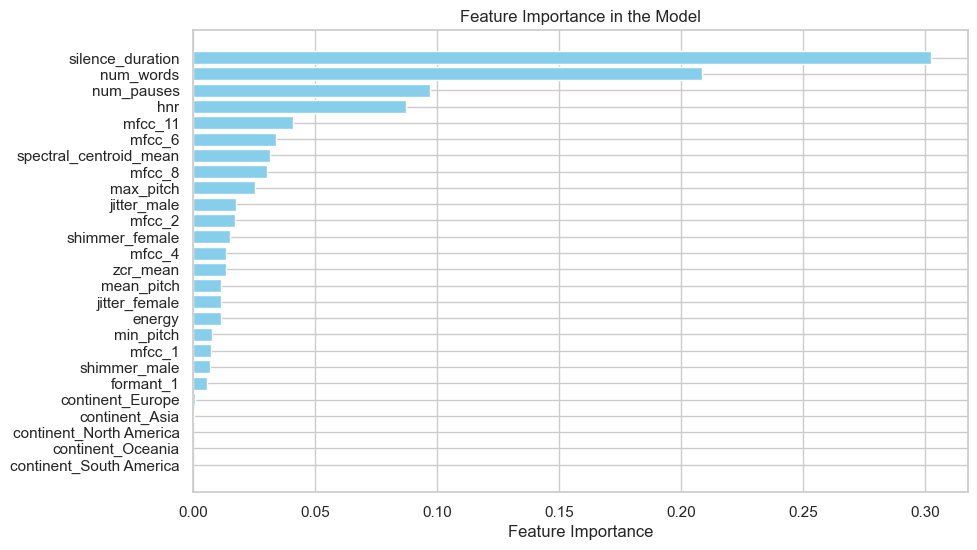

In [ ]:
#New combinations of parameters were tested to achieve optimal values while reducing overfitting.

X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.6, random_state=2529)
kf = KFold(n_splits=10, shuffle=True, random_state=2529)
rf_model1 = RandomForestRegressor(
    bootstrap=True,
    max_depth=5,
    max_features=0.5,
    min_samples_leaf=5,
    min_samples_split=50,
    n_estimators=200
)

scores_r2 = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()

scores_nmse = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()

print(f"R-squared: {rquadro}")
print(f"NMSE: {NMSE}")

rf_model1.fit(X_train, y_train)

y_pred = rf_model1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) on X_test: {np.sqrt(mse)}')

y_train_pred = rf_model1.predict(X_train)
y_test_pred = rf_model1.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")

if test_rmse - train_rmse > 0.1 * train_rmse:
    print("The model may be suffering from overfitting.")
else:
    print("The model appears to generalize well.")

feature_importances = rf_model1.feature_importances_

print(f"Length of feature_names: {len(X1.columns)}")
print(f"Length of feature_importances: {len(feature_importances)}")

importance_df = pd.DataFrame({
    'Feature': X1.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in the Model')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
#Following these results, the continents were removed, and new features were introduced to emphasize the less important features.

df_pp['pitch_range'] = (df_pp['max_pitch'] - df_pp['min_pitch'])**2


df_pp['voice_stability'] = (df_pp['jitter_male'] + df_pp['jitter_female'] +
                             df_pp['shimmer_male'] + df_pp['shimmer_female']) / 4

df_pp = df_pp.drop(['continent_North America','continent_Asia','continent_Europe','continent_Oceania',
                      'continent_South America'],axis=1)

In [ ]:
y1 = df_pp['age']
X1 = df_pp.drop(['age'],axis=1)


X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.6, random_state=2529)
kf = KFold(n_splits=10, shuffle=True, random_state=2529)
rf_model1 = RandomForestRegressor(
    bootstrap=True,
    max_depth=5,
    max_features=0.5,
    min_samples_leaf=5,
    min_samples_split=50,
    n_estimators=200
)
scores_r2 = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()
scores_nmse = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()
print(f"R-squared: {rquadro}")
print(f"NMSE: {NMSE}")
rf_model1.fit(X_train, y_train)

y_pred = rf_model1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) su X_test: {np.sqrt(mse)}')

# Calcola le predizioni
y_train_pred = rf_model1.predict(X_train)
y_test_pred = rf_model1.predict(X_test)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")

if test_rmse - train_rmse > 0.1 * train_rmse:
    print("The model may be suffering from overfitting.")
else:
    print("The model appears to generalize well.")

R-quadro: 0.31129001847326954
NMSE: -78.898732447031
Root Mean Squared Error (MSE) su X_test: 8.770032948340921
RMSE on training data: 8.22
RMSE on test data: 8.77
The model appears to generalize well.


In [ ]:
residuals = y_test - y_pred
errors = pd.DataFrame({'residuals': residuals, 'predicted': y_pred, 'actual': y_test})
errors = errors.sort_values(by=['residuals'], ascending=False)
print("Cases with high errors:")
print(errors.head(10))

Cases with high errors:
      residuals  predicted  actual
Id                                
910   33.434147  22.565853    56.0
2191  32.979083  23.020917    56.0
499   32.321678  27.678322    60.0
2082  31.235010  28.764990    60.0
2628  30.829869  29.170131    60.0
2695  30.184505  29.815495    60.0
951   29.588499  30.411501    60.0
661   29.441629  27.558371    57.0
1558  28.900635  30.099365    59.0
949   27.759244  32.240756    60.0


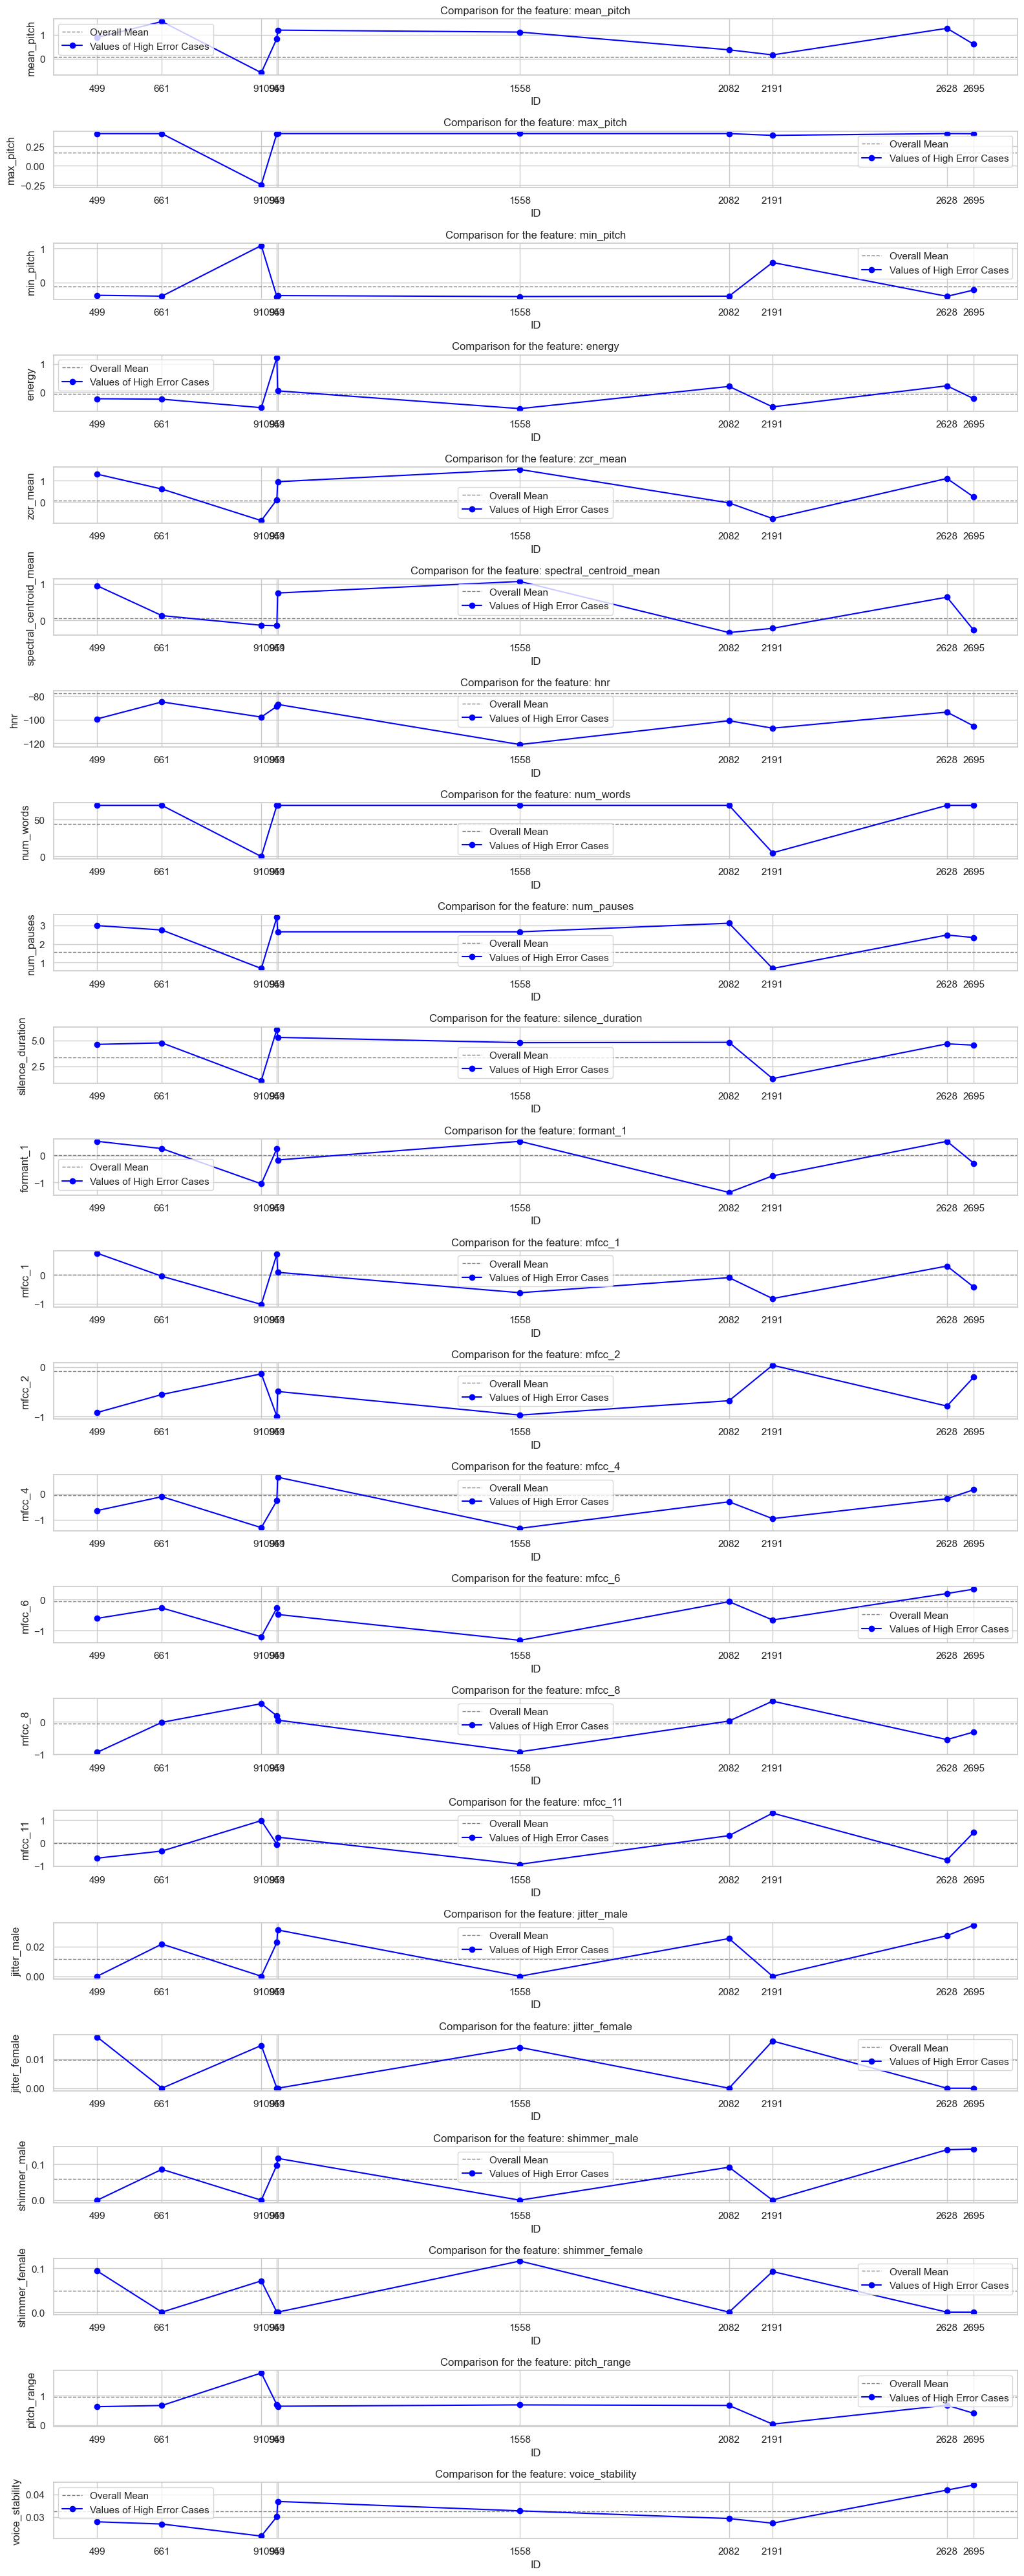

In [ ]:
error_ids = [910,2191,499,2628,2082,2695,1558,951,661,949]
error_cases = X1[X1.index.isin(error_ids)]
mean_values = X1.mean()

plt.figure(figsize=(16, 40))

for i, feature in enumerate(error_cases.columns):
    plt.subplot(len(error_cases.columns), 1, i + 1)
    plt.axhline(mean_values[feature], color='gray', linestyle='--', label='Overall Mean', linewidth=1)
    plt.plot(error_cases.index, error_cases[feature], marker='o', label='Values of High Error Cases', color='blue')
    plt.title(f'Comparison for the feature: {feature}')
    plt.xlabel('ID')
    plt.ylabel(feature)
    plt.xticks(error_cases.index)
    plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
#From the previous analyses, it emerges that the highest errors occur for individuals in the later part of the distribution (between 55 and 60 years
#old). The plots indicate that these individuals have an HNR lower than the average, so we will introduce a variable that emphasizes this result.
#Additionally, considering the small number of changes in this range, we will increase the training size to allow the model to also learn from these
#cases.

mean_hnr = df_pp['hnr'].mean()

df_pp['hnr_diff'] = (df_pp['hnr'] - mean_hnr)**2

y1 = df_pp['age']
X1 = df_pp.drop(['age'],axis=1)


X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.85, random_state=2529)

kf = KFold(n_splits=10, shuffle=True, random_state=2529)
rf_model1 = RandomForestRegressor(
    bootstrap=True,
    max_depth=5,
    max_features=0.5,
    min_samples_leaf=5,
    min_samples_split=50,
    n_estimators=200
)

scores_r2 = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()

scores_nmse = cross_val_score(rf_model1, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()


print(f"R-squared: {rquadro}")
print(f"NMSE: {NMSE}")

rf_model1.fit(X_train, y_train)

y_pred = rf_model1.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) su X_test: {np.sqrt(mse)}')


y_train_pred = rf_model1.predict(X_train)
y_test_pred = rf_model1.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")

R-quadro: 0.3138992180372441
NMSE: -78.80708553125314
Root Mean Squared Error (MSE) su X_test: 8.192498397494761
RMSE on training data: 8.35
RMSE on test data: 8.19


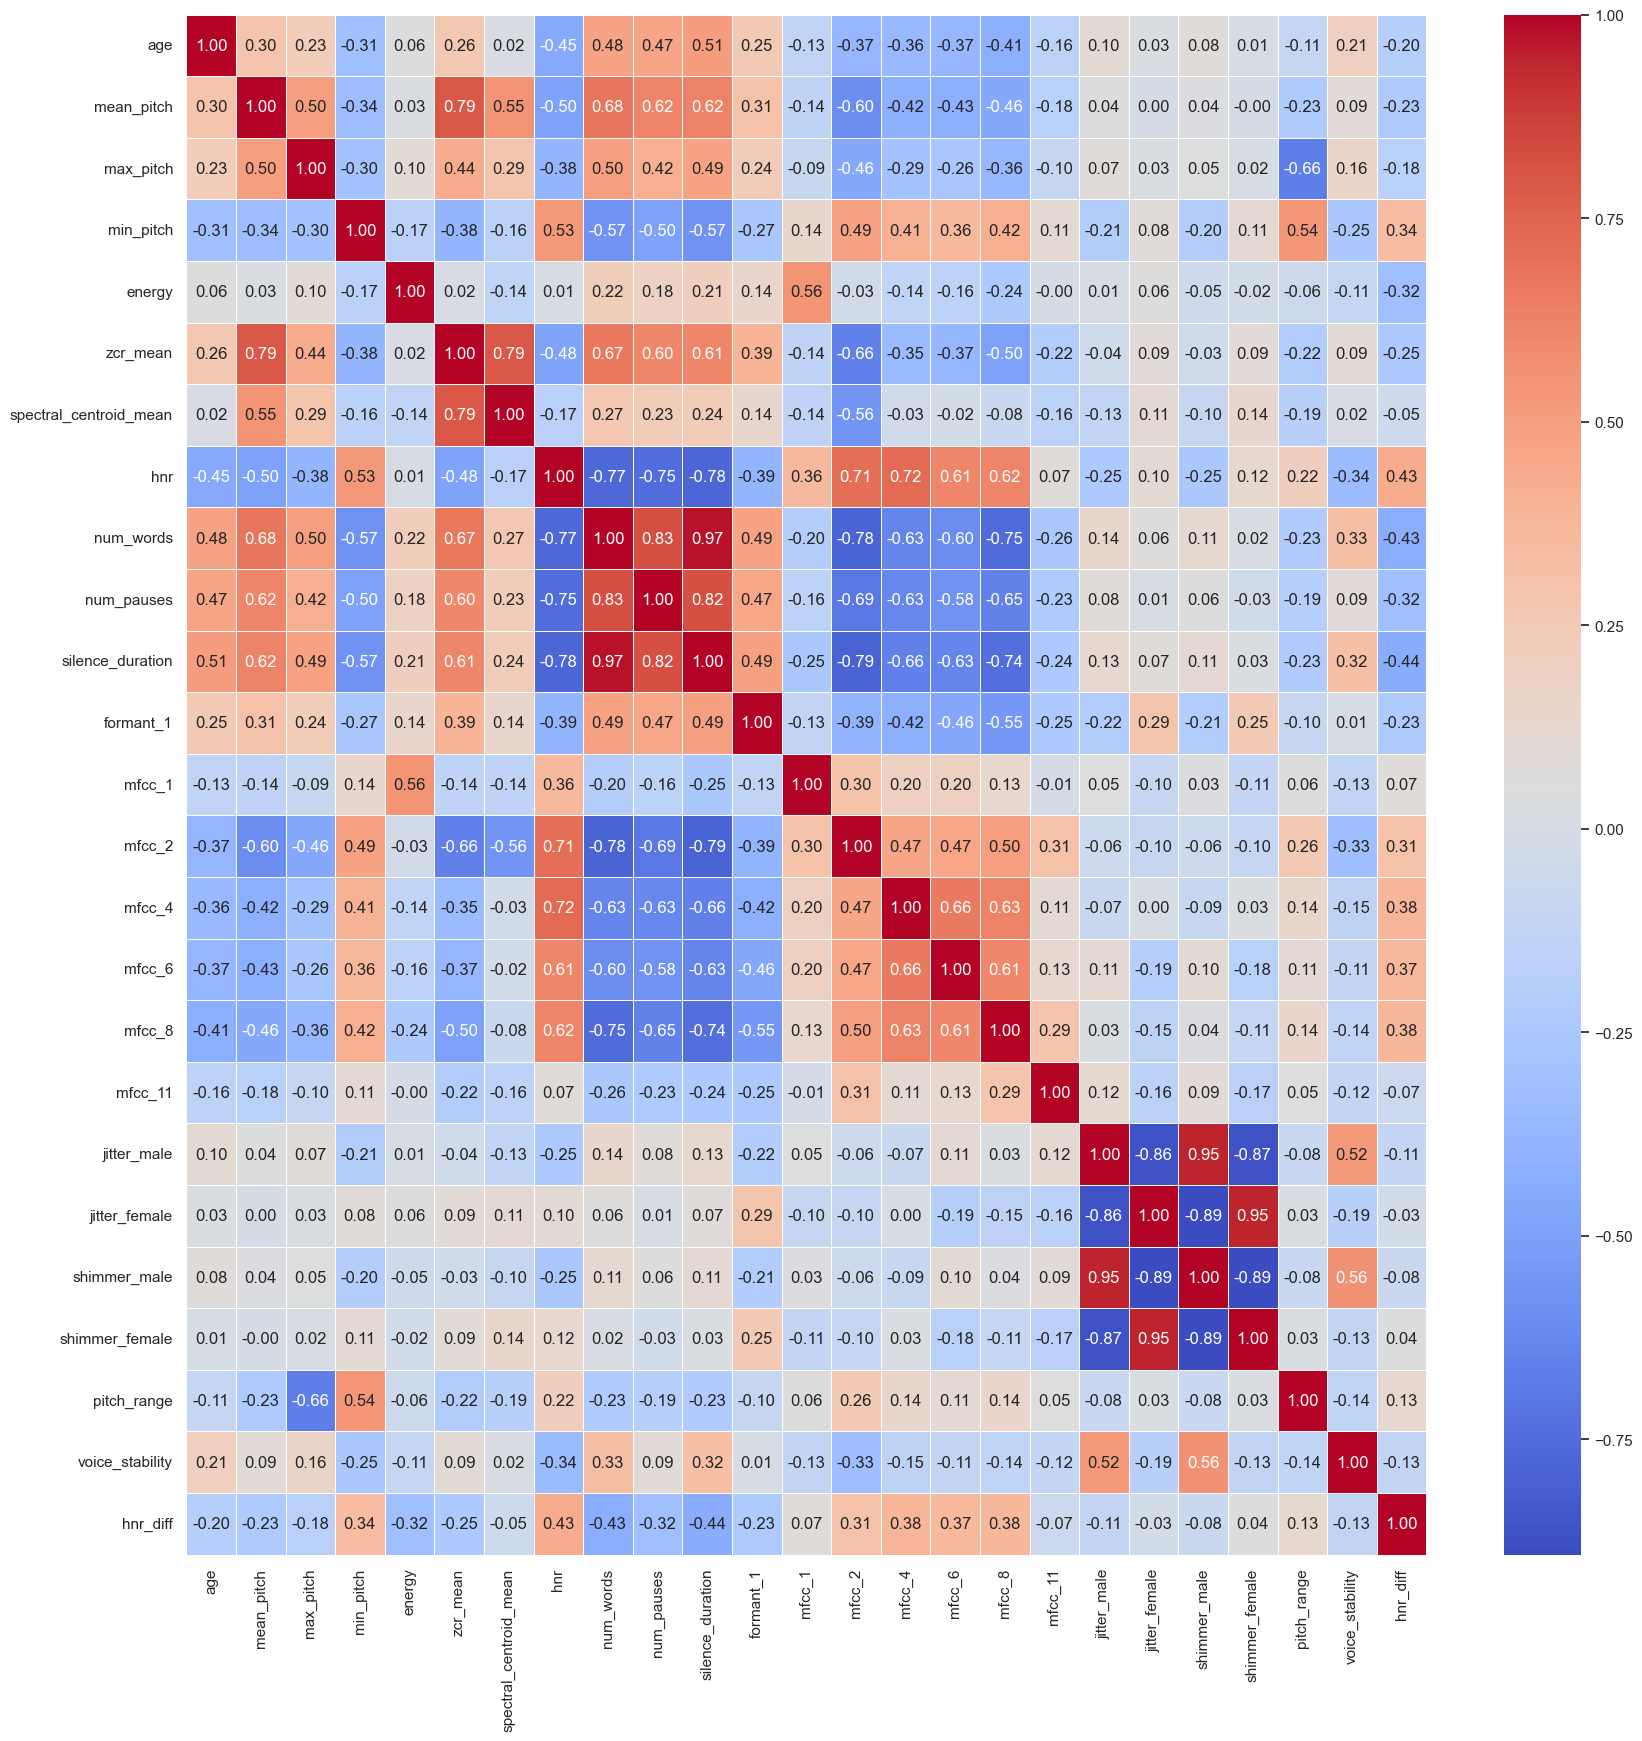

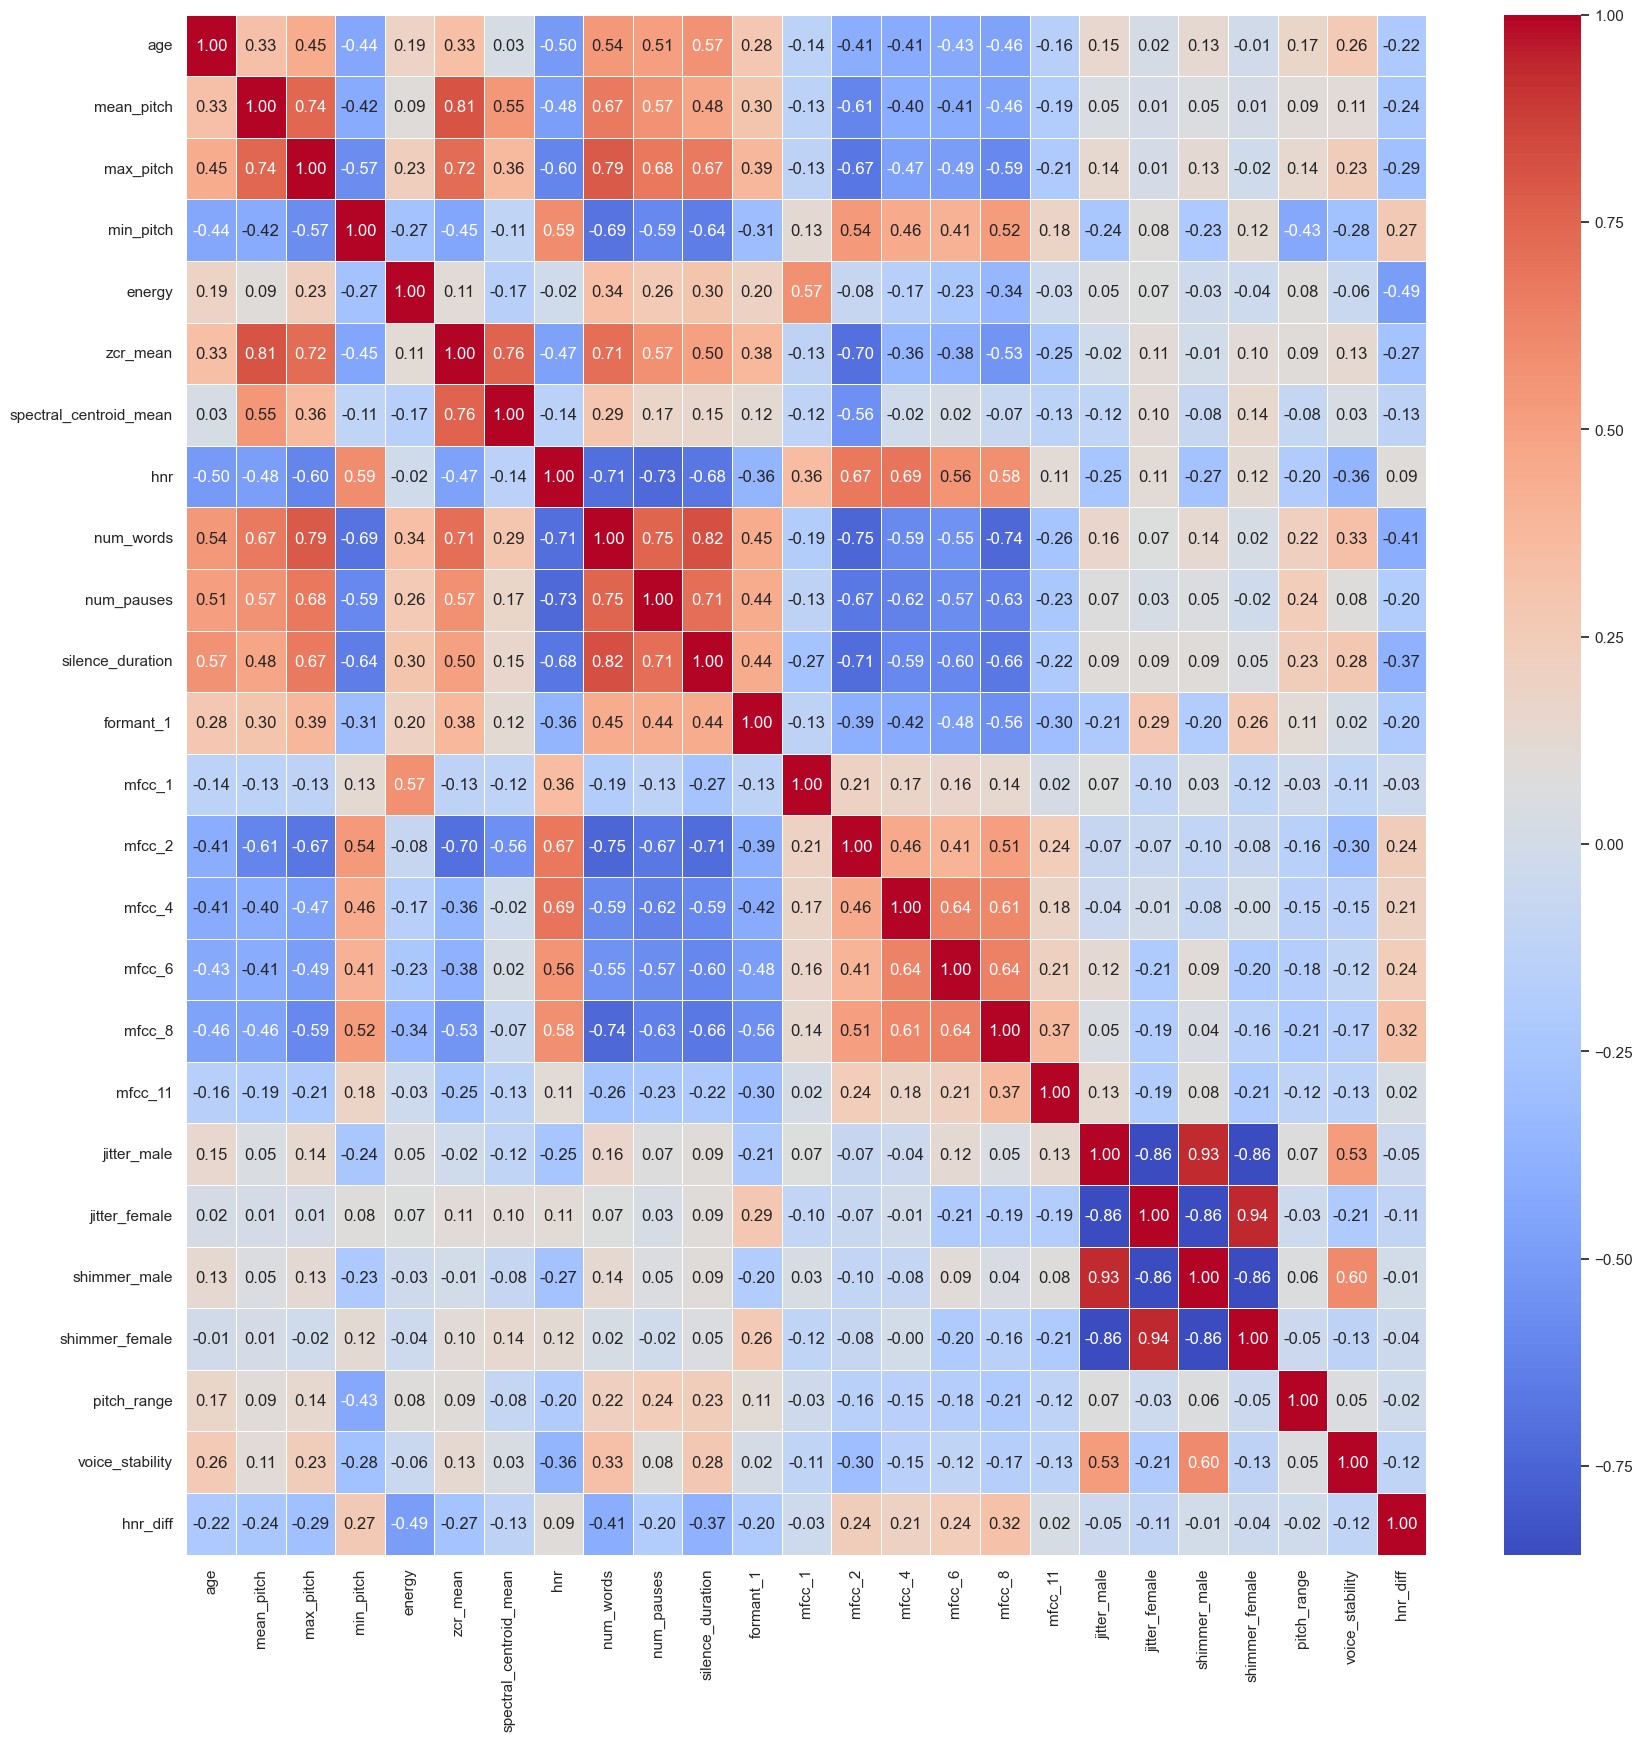

In [ ]:
plt.figure(figsize=(20,20))
sns.heatmap(df_pp.corr(),annot=True,linewidths=0.6,fmt=".2f",cmap="coolwarm");

plt.figure(figsize=(20,20))
sns.heatmap(df_pp.corr(method='spearman'),annot=True,linewidths=0.6,fmt=".2f",cmap="coolwarm");

In [ ]:
#From the correlation plot, it emerges that the correlation between age and some variables increases when we
#consider Spearman correlation, which also identifies nonlinear relationships. Therefore, it is appropriate to proceed by
#introducing non-linearity through polynomial features.


y1 = df_pp['age']
X1 = df_pp.drop(['age'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.85, random_state=2529)

kf = KFold(n_splits=10, shuffle=True, random_state=2529)
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),  # You can adjust the degree
    ('rf_model', RandomForestRegressor(
        bootstrap=True,
        max_depth=5,
        max_features=0.5,
        min_samples_leaf=5,
        min_samples_split=50,
        n_estimators=200
    ))
])
scores_r2 = cross_val_score(pipeline, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()
scores_nmse = cross_val_score(pipeline, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()
print(f"R-squared: {rquadro}")
print(f"NMSE: {NMSE}")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) on X_test: {np.sqrt(mse)}')
y_train_pred = pipeline.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")
if test_rmse - train_rmse > 0.1 * train_rmse:
    print("The model may be suffering from overfitting.")
else:
    print("The model appears to generalize well.")


R-quadro: 0.3151201252971879
NMSE: -78.21374817651598
Root Mean Squared Error (MSE) on X_test: 8.182894151154326
RMSE on training data: 8.06
RMSE on test data: 8.18
The model appears to generalize well.


In [ ]:
y1 = df_pp['age']
X1 = df_pp.drop(['age'],axis=1)
pipe = make_pipeline(PolynomialFeatures(), RandomForestRegressor())

param_grid = {
    'polynomialfeatures__degree': [1, 2],
    'randomforestregressor__n_estimators': [100, 200, 300],  # Number of trees
    'randomforestregressor__max_depth': [4, 6, 8],  # Maximum depth of the trees
    'randomforestregressor__min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'randomforestregressor__min_samples_leaf': [1, 2, 5],  # Minimum samples in a leaf node
    'randomforestregressor__max_features': [None, 'sqrt', 'log2'],  # Features to consider when looking for splits
    'randomforestregressor__bootstrap': [True, False],  # Use bootstrap samples or not
}

X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.85, random_state=2529)
search = GridSearchCV(pipe, param_grid, n_jobs=-1, scoring='neg_mean_squared_error')
search.fit(X_train, y_train)
print("Best parameters (CV score=%0.3f):" % search.best_score_)
print(search.best_params_)
y_pred = search.best_estimator_.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Root Mean Squared Error (RMSE) on test set: {rmse}')
y_train_pred = search.best_estimator_.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f'Root Mean Squared Error (RMSE) sul training set: {rmse_train}')


Best parameters (CV score=-79.317):
{'polynomialfeatures__degree': 2, 'randomforestregressor__bootstrap': True, 'randomforestregressor__max_depth': 8, 'randomforestregressor__max_features': 'sqrt', 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100}
Root Mean Squared Error (RMSE) on test set: 8.171096406452964
Root Mean Squared Error (RMSE) sul training set: 6.840562994819832


In [ ]:
#The results obtained from hyperparameter tuning using grid search are reported below and will be applied in the following code.

{'polynomialfeatures__degree': 2, 'randomforestregressor__bootstrap': False,
 'randomforestregressor__max_depth': 8, 'randomforestregressor__max_features': 'sqrt',
 'randomforestregressor__min_samples_leaf': 5, 'randomforestregressor__min_samples_split': 10,
 'randomforestregressor__n_estimators': 200}



{'polynomialfeatures__degree': 2,
 'randomforestregressor__bootstrap': False,
 'randomforestregressor__max_depth': 8,
 'randomforestregressor__max_features': 'sqrt',
 'randomforestregressor__min_samples_leaf': 5,
 'randomforestregressor__min_samples_split': 10,
 'randomforestregressor__n_estimators': 200}

In [ ]:
y1 = df_pp['age']
X1 = df_pp.drop(['age'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.85, random_state=2529)
kf = KFold(n_splits=10, shuffle=True, random_state=2529)
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('rf_model', RandomForestRegressor(
        bootstrap=False,
        max_depth=8,
        max_features='sqrt',
        min_samples_leaf=5,
        min_samples_split=10,
        n_estimators=200
    ))
])

scores_r2 = cross_val_score(pipeline, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()
scores_nmse = cross_val_score(pipeline, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()
print(f"R-squared: {rquadro}")
print(f"NMSE: {NMSE}")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) on X_test: {np.sqrt(mse)}')
y_train_pred = pipeline.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")


R-quadro: 0.32646556814624006
NMSE: -76.88541278146553
Root Mean Squared Error (RMSE) on X_test: 8.15445489454216
RMSE on training data: 6.12
RMSE on test data: 8.15


### **Analysis of results**

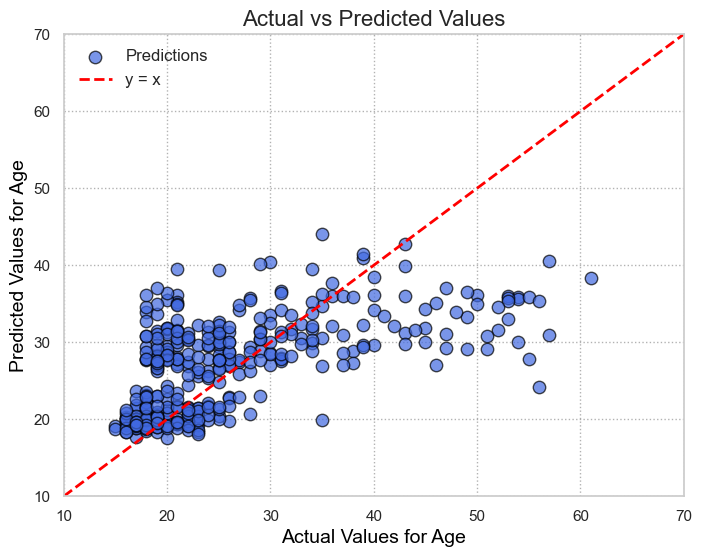

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='royalblue', alpha=0.7, edgecolors='black', s=80, label='Predictions')

plt.title('Actual vs Predicted Values', fontsize=16)
plt.xlabel('Actual Values for Age', fontsize=14, color='black')
plt.ylabel('Predicted Values for Age', fontsize=14, color='black')

plt.xlim(10, 70)
plt.ylim(10, 70)

plt.plot([10, 70], [10, 70], color='red', linestyle='--', linewidth=2, label='y = x', zorder=2)

plt.legend(fontsize=12, loc='upper left', frameon=False)

plt.grid(True, linestyle=':', color='gray', alpha=0.6)

plt.show()


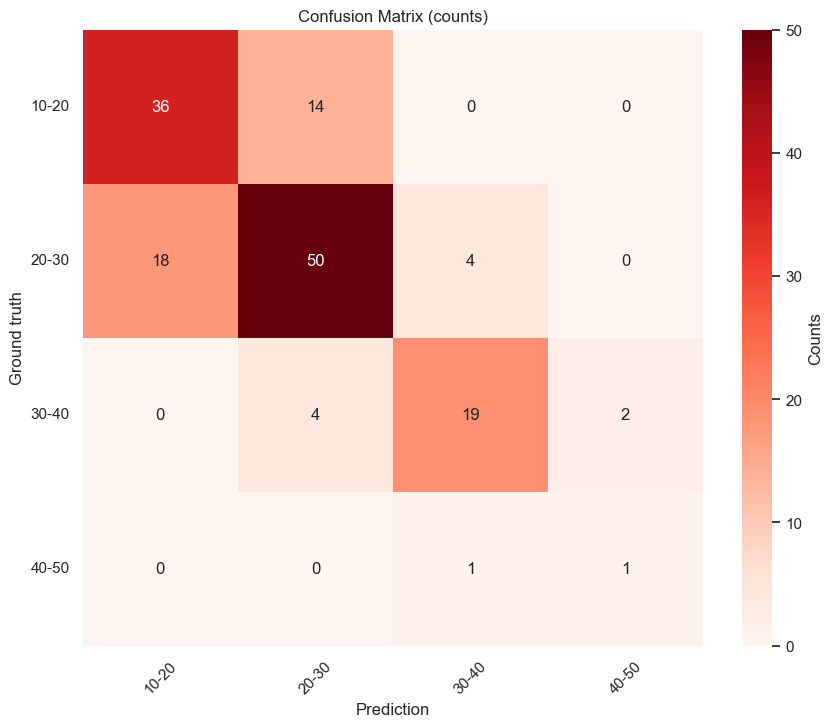

In [ ]:
def create_age_groups(predictions, actuals):
    age_groups = {}
    for age in range(10, 50, 10):
        age_groups[f"{age}-{age + 10}"] = {'actual': [], 'pred': []}
    for pred, actual in zip(predictions, actuals):
        for group in age_groups:
            lower_bound = int(group.split('-')[0])
            upper_bound = int(group.split('-')[1])
            if lower_bound <= actual < upper_bound:
                age_groups[group]['actual'].append(actual)
                if (actual - 3) <= pred <= (actual + 3):
                    age_groups[group]['pred'].append(pred)

    return age_groups

age_groups = create_age_groups(y_pred, y_test)
group_labels = list(age_groups.keys())
conf_matrix = np.zeros((len(group_labels), len(group_labels)))
for i, group_i in enumerate(group_labels):
    for j, group_j in enumerate(group_labels):
        pred_correct = sum((np.array(age_groups[group_i]['pred']) >= int(group_j.split('-')[0])) &
                           (np.array(age_groups[group_i]['pred']) < int(group_j.split('-')[1])))
        conf_matrix[i, j] = pred_correct

conf_matrix_counts_df = pd.DataFrame(conf_matrix, index=group_labels, columns=group_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_counts_df, annot=True, fmt=".0f", cmap="Reds", cbar=True,
            cbar_kws={'label': 'Counts'})
plt.title("Confusion Matrix (counts)")
plt.xlabel("Prediction")
plt.ylabel("Ground truth")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


## Final Model

In [ ]:
df_pp = df_endpreprocessing

y1 = df_pp['age']
X1 = df_pp.drop(['age'],axis=1)
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

df_pp['pitch_range'] = (df_pp['max_pitch'] - df_pp['min_pitch'])**2


df_pp['voice_stability'] = (df_pp['jitter_male'] + df_pp['jitter_female'] +
                             df_pp['shimmer_male'] + df_pp['shimmer_female']) / 4

df_pp = df_pp.drop(['continent_North America','continent_Asia','continent_Europe','continent_Oceania',
                      'continent_South America'],axis=1)

mean_hnr = df_pp['hnr'].mean()
df_pp['hnr_diff'] = (df_pp['hnr'] - mean_hnr)**2


y1 = df_pp['age']
X1 = df_pp.drop(['age'], axis=1)


X_train, X_test, y_train, y_test = train_test_split(X1, y1, train_size=0.85, random_state=2529)
kf = KFold(n_splits=10, shuffle=True, random_state=2529)
pipeline = Pipeline([
    ('poly_features', PolynomialFeatures(degree=2, include_bias=False)),
    ('rf_model', RandomForestRegressor(
        bootstrap=False,
        max_depth=8,
        max_features='sqrt',
        min_samples_leaf=5,
        min_samples_split=10,
        n_estimators=200
    ))
])

scores_r2 = cross_val_score(pipeline, X1, y1, cv=kf, scoring='r2', n_jobs=-1)
rquadro = scores_r2.mean()
scores_nmse = cross_val_score(pipeline, X1, y1, cv=kf, scoring='neg_mean_squared_error', n_jobs=-1)
NMSE = scores_nmse.mean()
print(f"R-quadro: {rquadro}")
print(f"NMSE: {NMSE}")
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Root Mean Squared Error (RMSE) on X_test: {np.sqrt(mse)}')
y_train_pred = pipeline.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE on training data: {train_rmse:.2f}")
print(f"RMSE on test data: {test_rmse:.2f}")


R-quadro: 0.3265160229717324
NMSE: -76.84887924355692
Root Mean Squared Error (RMSE) on X_test: 8.129128830731698
RMSE on training data: 6.08
RMSE on test data: 8.13


## Evaluation

In [ ]:
path_ev=r"C:\Users\iparo\Desktop\magi\Data Science Lab\Untitled Folder\DSL_Winter_Project_2025\audios_evaluation"

dict_audio_ev = {}
dict_audio_ev = {
    int(os.path.splitext(file)[0]): os.path.join(path_ev, file)
    for file in os.listdir(path_ev)
    if file.endswith(".wav")
}

In [ ]:
dict_audio_denoised_ev = {}
for key, file_path in dict_audio_ev.items():
        y, sr = librosa.load(file_path, sr=None)
        reduced_noise = nr.reduce_noise(y=y, sr=sr, stationary=False)
        dict_audio_denoised_ev[key] = (reduced_noise, sr)


In [ ]:
dataFrameAudio_ev = []
index_audio_ev = []

for key,(audio,sr)  in dict_audio_denoised_ev.items():
    features = features_extraction(audio, sr)
    dataFrameAudio_ev.append(features)
    index_audio_ev.append(key)

In [ ]:
df_pp_ev = df_eval.drop(columns=['ethnicity','num_characters','sampling_rate','tempo'])
audio_id=df_pp_ev['path'].str.extract(r'(\d+)\.wav').astype(int)
df_pp_ev['audio_id'] = audio_id
df_ev = pd.DataFrame(dataFrameAudio_ev, index=index_audio_ev)
df_ev.index = df_ev.index.astype(int)
df_ev = df_ev.sort_index()
result_ev = pd.merge(df_pp_ev, df_ev, right_index=True, left_on='audio_id')
display(result_ev)

,gender,mean_pitch,max_pitch,min_pitch,jitter,shimmer,energy,zcr_mean,spectral_centroid_mean,hnr,...,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12
Id,,,,,,,,,,,,,,,,,,,,,
0,male,1056.91740,3945.1610,145.38750,0.022082,0.171076,0.003136,0.032963,1549.607050,-116.662338,...,2.210797,18.464279,11.274241,4.310649,-1.191183,-2.566468,4.815361,-3.904608,-4.891016,0.948150
1,male,1231.84570,3999.1720,145.56432,0.026571,0.132585,0.006783,0.123895,2344.817369,-78.253824,...,10.418957,30.308826,7.526682,10.667743,2.178771,0.485001,-6.440629,-7.247090,-5.633719,-10.282423
2,male,958.29065,3445.4490,145.67374,0.018044,0.096289,0.004478,0.089149,1939.574896,-71.630742,...,2.972573,16.811907,9.597748,16.061209,-4.926746,-1.004643,-2.890360,-4.488954,1.142332,-0.261298
3,female,1396.54170,3998.8948,145.41223,0.027290,0.088901,0.014893,0.097054,1832.059113,-101.533013,...,10.661545,18.351137,13.678084,8.174952,-0.764037,-3.201520,-3.021292,-5.612882,-4.406858,-5.839260
4,male,1633.86770,3999.7632,145.36313,0.021621,0.103855,0.001369,0.140950,2534.611168,-134.914070,...,4.139848,17.194057,9.473201,8.048149,-2.030462,3.553612,-7.288966,-6.273836,-5.362905,-3.460040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,male,570.62740,3900.6730,145.67577,0.018842,0.079197,0.004545,0.072083,1946.502158,-42.895295,...,34.465691,24.933859,19.560339,15.471129,-1.994407,-0.083742,-1.151662,0.820645,-6.456336,5.596154
687,male,974.13965,3919.0024,145.90408,0.024367,0.117492,0.000878,0.076900,3319.620800,-144.881089,...,10.076231,9.410297,5.654107,9.238719,1.674571,2.271369,-0.336251,0.073801,2.224159,3.037697
688,female,1113.27650,3999.3510,145.38307,0.020637,0.089355,0.009148,0.095613,1973.127197,-73.559944,...,16.444059,22.972582,6.628843,6.124150,-7.443666,-7.487540,-11.022635,-5.547438,-8.598029,-6.461251


In [ ]:
result_ev = result_ev.drop(columns=['path', 'audio_id','mfcc_12', 'mfcc_7', 'mfcc_3', 'mfcc_9', 'mfcc_10',  'mfcc_5'])


In [ ]:
result_ev['jitter_male'] = np.where(result_ev['gender'] == 'male', result_ev['jitter'], 0)
result_ev['jitter_female'] = np.where(result_ev['gender'] == 'female', result_ev['jitter'], 0)

result_ev['shimmer_male'] = np.where(result_ev['gender'] == 'male', result_ev['shimmer'], 0)
result_ev['shimmer_female'] = np.where(result_ev['gender'] == 'female', result_ev['shimmer'], 0)

result_ev = result_ev.drop(['jitter', 'shimmer','gender'], axis=1)
result_ev[zscore_features] = scaler.transform(result_ev[zscore_features])

for feature in iqr_features:
    if feature in lambda_values:
        if (result_ev[feature] <= 0).any():
            print(f"Warning: {feature} in evaluation set contains non-positive values. Box-Cox transformation cannot be applied.")
        else:
            result_ev[feature] = boxcox(result_ev[feature], lmbda=lambda_values[feature])
            print(f"Applied Box-Cox transformation to {feature} in evaluation set.")


result_ev['pitch_range'] =result_ev['max_pitch'] - result_ev['min_pitch']
result_ev['voice_stability'] = (result_ev['jitter_male'] + result_ev['jitter_female'] +
                         result_ev['shimmer_male'] + result_ev['shimmer_female']) / 4
result_ev['hnr_diff'] = (result_ev['hnr'] - mean_hnr) **2


Applied Box-Cox transformation to silence_duration in evaluation set.
Applied Box-Cox transformation to num_pauses in evaluation set.


In [ ]:
predictions = pipeline.predict(result_ev)
df_predictions = pd.DataFrame({
    'Id': result_ev.index,
    'Predicted': predictions
})
df_predictions.to_csv('predictions5555.csv', index=False)
print("File saved")

File saved


## Random Guess

In [ ]:
stats = y_train.describe()
mean_age = stats['mean']
std_age = stats['std']
print(stats)

count    2155.000000
mean       27.219722
std        10.845923
min         6.000000
25%        19.000000
50%        23.000000
75%        32.000000
max        61.000000
Name: age, dtype: float64


In [ ]:
stats_test = y_test.describe()
num_predictions = stats_test['count'].astype(int)
print(stats_test)

count    381.000000
mean      26.002625
std        9.987755
min       15.000000
25%       19.000000
50%       22.000000
75%       30.000000
max       61.000000
Name: age, dtype: float64


In [ ]:
# Model where the target variable follows a normal distribution with mean and standard deviation of the training set
np.random.seed(42)
random_predictions = np.random.normal(loc=mean_age, scale=std_age, size=num_predictions)
r2_random = r2_score(y_test, random_predictions)
print(f"Random Guess R-squared (Test Set): {r2_random}")
rmse_random = np.sqrt(mean_squared_error(y_test, random_predictions))
print(f"Random Guess RMSE (Test Set): {rmse_random}")

Random Guess R-squared (Test Set): -0.9438373646132092
Random Guess RMSE (Test Set): 13.906798680852377


## Naive solution

In [ ]:
# Model that predict the mean age for all the samples
naive_predictions_test = np.full_like(y_test, mean_age)

rmse_naive_test = np.sqrt(mean_squared_error(y_test, naive_predictions_test))
r2_naive_test = r2_score(y_test, naive_predictions_test)

print(f"Naive Solution R-squared (Test Set): {r2_naive_test}")
print(f"Naive Solution RMSE (Test Set): {rmse_naive_test}")


Naive Solution R-squared (Test Set): -0.014888670104373114
Naive Solution RMSE (Test Set): 10.048619622089399
